# Recipe Site Traffic — Predicting High-Traffic Recipes for the Tasty Bytes Homepage

**Prepared for:** the Head of Data Science (technical review) and the Product Manager, Recipe Discovery (business decision)
**Data:** `Data/recipe_site_traffic_2212.csv` — one row per recipe, 947 recipes, 8 columns

---

## The request

The Product Manager currently hand-picks one recipe per day for the Tasty Bytes homepage. When the
pick is popular, traffic to the rest of the site rises by **as much as 40%**, and more traffic means
more subscriptions. Two questions were asked:

1. Can we **predict which recipes will lead to high traffic**?
2. Can we do it **correctly 80% of the time**?

## How this notebook answers them

The second question needs a precise reading before it can be tested. Only **one** recipe is featured
per day, and it is chosen from a **pool of candidates**, so the two kinds of error are not symmetric:

- A **false positive** — recommending a recipe that turns out to be unpopular — burns the homepage slot
  for a whole day and costs real traffic.
- A **false negative** — passing over a recipe that would have been popular — costs almost nothing,
  because another good candidate is available and that recipe can be featured another day.

So *"correctly predict high traffic 80% of the time"* is implemented here as
**precision on the High class ≥ 0.80**: *of the recipes we recommend, at least 8 in 10 must actually
achieve high traffic.* This is also the direct operationalisation of *"minimise the chance of showing
unpopular recipes"*. Accuracy and recall are reported for completeness but are **not** the target —
accuracy rewards being right about recipes we would never feature, and recall rewards catching every
popular recipe, which is not the business problem when there is only one slot per day.

## Structure

| Section | Contents |
|---|---|
| 1 | Data validation — every column against the data dictionary, with the cleaning action taken |
| 2 | Exploratory analysis — single-variable and multi-variable graphics, and what they mean commercially |
| 3 | Model development — problem type, baseline model, comparison model |
| 4 | Model evaluation — comparison table, precision-recall curves, threshold tuning, recommendation |
| 5 | Business metric — a metric the Product Manager can monitor, and its initial value |
| 6 | Final summary and recommendations |

Every number quoted in the written summaries and in the presentation is produced by a cell in this
notebook; nothing is carried in from an earlier exploration. The final cell writes `key_numbers.md`,
which is the single source of figures for the presentation.

In [1]:
# --- CELL 0.1 --- Environment, seeds, house style and data load
import warnings, platform
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix, classification_report)

# Reproducibility: one seed drives every stochastic step (the split, the forest, the CV shuffles).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Chart styling -------------------------------------------------------------------
# A two-hue categorical palette (blue / orange), checked for colour-vision-deficiency
# separation and for >= 3:1 contrast against a white surface. Blue carries magnitude and the
# "High traffic" class throughout, orange the contrasting class; grid and axes stay recessive
# so the data marks dominate. No chart below uses two y-scales or more hues than it needs.
C_BLUE, C_ORANGE, C_GRAY, C_RED = "#2a78d6", "#eb6834", "#8a8a85", "#e34948"
C_BLUE_LT, C_BLUE_DK = "#9ec5f4", "#184f95"
INK, INK_2 = "#0b0b0b", "#52514e"

mpl.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 200, "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff", "axes.edgecolor": "#d5d4d0", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 10, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5, "grid.color": "#ebeae6", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5, "font.size": 10.5,
    "lines.linewidth": 2.0, "figure.autolayout": False,
})


def finish(ax, title, xlabel=None, ylabel=None, grid_axis="y"):
    '''Apply the house style: left-aligned title, axis labels, recessive grid behind the marks.'''
    ax.set_title(title, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if grid_axis:
        ax.grid(True, axis=grid_axis, zorder=0)
        ax.set_axisbelow(True)
    return ax


# --- Key-number register -------------------------------------------------------------
# Every figure the presentation is allowed to quote is registered here with the cell that
# produced it. The final cell writes them all to key_numbers.md, so no slide can contain a
# number that this notebook did not compute.
KEY = {}


def keep(label, value, cell, fmt=None, group="General"):
    KEY[label] = {"value": value, "cell": cell, "fmt": fmt, "group": group}
    return None       # returns nothing, so a trailing keep() call prints no stray output


# Paths are relative to this notebook's own folder, so it runs when launched from analysis/.
# Lowercase "data" on purpose: Windows would tolerate "Data", Linux and DataLab would not.
# NOTE: on DataLab the CSV sits beside the workbook, so DATA_PATH loses the "../" there.
DATA_PATH = "../data/recipe_site_traffic_2212.csv"
DATA_PATH_DISPLAY = "data/recipe_site_traffic_2212.csv"   # as seen from the repo root
KEY_NUMBERS_PATH = "key_numbers.md"                       # written beside this notebook
NUTRIENTS = ["calories", "carbohydrate", "sugar", "protein"]
# The ten categories the data dictionary says we should see.
DOCUMENTED_CATEGORIES = ["Lunch/Snacks", "Beverages", "Potato", "Vegetable", "Meat",
                         "Chicken", "Pork", "Dessert", "Breakfast", "One Dish Meal"]

raw = pd.read_csv(DATA_PATH)   # read-only: the source file is never modified
print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | matplotlib {mpl.__version__}")
print(f"Loaded {DATA_PATH} -> {raw.shape[0]} rows x {raw.shape[1]} columns")

python 3.13.2 | pandas 2.2.3 | numpy 2.2.3 | scikit-learn 1.6.1 | matplotlib 3.10.0
Loaded ../data/recipe_site_traffic_2212.csv -> 947 rows x 8 columns


---
# 1. Data validation

The brief warns explicitly: *"Don't forget to double check the data really does match what they say —
it might not."* Each of the eight columns is therefore checked against the data dictionary and given an
explicit action, in the same three-part form:

> **Documented** — what the data dictionary promises · **Found** — what the file actually contains ·
> **Action** — what was done, and why.

Four genuine discrepancies were found. They are flagged as **DISCREPANCY** where they arise and
collected in the summary table at the end of the section.

In [2]:
# --- CELL 1.1 --- Structural overview: shape, dtypes, missingness, duplication
n_rows, n_cols = raw.shape
keep("Rows in the raw dataset", n_rows, "1.1", "{:,}", "Dataset")
keep("Columns in the raw dataset", n_cols, "1.1", "{:,}", "Dataset")

overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_null": raw.notna().sum(),
    "missing": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(2),
    "n_unique": raw.nunique(dropna=True),
})
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} columns\n")
print(overview.to_string())

n_dup_full = int(raw.duplicated().sum())
n_dup_id = int(raw["recipe"].duplicated().sum())
keep("Fully duplicated rows", n_dup_full, "1.1", "{:,}", "Dataset")
print(f"\nFully duplicated rows: {n_dup_full}   |   Duplicated recipe ids: {n_dup_id}")
raw.head()

Shape: 947 rows x 8 columns

                dtype  non_null  missing  missing_pct  n_unique
recipe          int64       947        0         0.00       947
calories      float64       895       52         5.49       891
carbohydrate  float64       895       52         5.49       835
sugar         float64       895       52         5.49       666
protein       float64       895       52         5.49       772
category       object       947        0         0.00        11
servings       object       947        0         0.00         6
high_traffic   object       574      373        39.39         1

Fully duplicated rows: 0   |   Duplicated recipe ids: 0


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


### 1.1 `recipe`

- **Documented:** numeric, unique identifier of the recipe.
- **Found:** integer, 947 values, all unique, running 1…947 with no gaps and no duplicated rows
  (cells 1.1 and 1.2). The column matches its specification exactly.
- **Action:** used to confirm one row per recipe, then **dropped from the feature set**. An identifier
  carries no information about how popular a recipe is; keeping it would let a model memorise
  individual recipes instead of learning something transferable, and it could not be used to score a
  brand-new recipe — which is exactly what the Product Manager needs.

In [3]:
# --- CELL 1.2 --- recipe: uniqueness, range and completeness of the id sequence
rid = raw["recipe"]
expected = pd.RangeIndex(rid.min(), rid.max() + 1)
print(f"dtype                : {rid.dtype}")
print(f"unique values        : {rid.nunique():,} of {len(rid):,} rows -> "
      f"{'unique, one row per recipe' if rid.is_unique else 'DUPLICATES PRESENT'}")
print(f"range                : {rid.min()} .. {rid.max()}")
print(f"gaps in the sequence : {len(expected.difference(rid))}")
print(f"missing values       : {int(rid.isna().sum())}")

dtype                : int64
unique values        : 947 of 947 rows -> unique, one row per recipe
range                : 1 .. 947
gaps in the sequence : 0
missing values       : 0


### 1.2 `calories`, `carbohydrate`, `sugar`, `protein`

- **Documented:** numeric — calories, and grams of carbohydrate, sugar and protein. The example recipe
  on page 3 of the brief quotes nutrition **per serving**, which is how these values are read here.
- **Found:** all four are `float64`. All values are **strictly positive** except two recipes recording
  `protein = 0`, which is plausible — a fruit juice or a plain vegetable side has essentially no
  protein — so those are treated as real measurements, not errors. All four distributions are strongly
  right-skewed: the median calorie count is far below the mean and the maximum runs into the thousands.
- **DISCREPANCY — 52 rows have all four nutrition values missing.** The missingness is not scattered.
  The pattern table below shows exactly **two** patterns in the whole dataset: all four present
  (895 rows) or all four absent (52 rows). Nothing is ever partially missing. That is the signature of
  a recipe whose nutrition panel was never filled in, rather than of four independent measurement
  failures.

**Action — impute, and keep the fact that it was imputed.** These 52 rows are 5.5% of the data and, as
cell 2.5 shows, they reach high traffic *more* often than the rest. Dropping them would throw away both
the rows and that signal. So:

1. A binary indicator **`nutrition_missing`** records that the panel was absent. It is derived from the
   row itself, so it can be computed before any train/test split without leaking anything.
2. The missing values are filled with the **median of the recipe's own `category`** — a Beverage and a
   One Dish Meal have very different nutrition profiles, so one global median would be a poor guess —
   with a **fallback to the global median** if a category were to contain no complete rows. The median
   rather than the mean, because these distributions are heavily skewed and a mean would be dragged
   upward by the large multi-serving recipes.
3. **The medians are computed on the training split only** and then mapped onto both splits. This
   happens inside the model pipeline (section 3.3), *not* here — see the note at the end of this
   section.

`protein = 0` is left as measured; there is no basis for overwriting a legitimate zero.

In [4]:
# --- CELL 1.3 --- Nutrition columns: types, distribution shape and the missingness pattern
print("Dtypes:")
print(raw[NUTRIENTS].dtypes.to_string(), "\n")
print("Summary statistics over the 895 complete rows:")
print(raw[NUTRIENTS].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
      .round(2).to_string())

print("\nNon-positive values (would break a log scale, or signal a data-entry error):")
print(pd.DataFrame({"zeros": (raw[NUTRIENTS] == 0).sum(),
                    "negatives": (raw[NUTRIENTS] < 0).sum()}).to_string())

print("\nMissingness patterns across the four nutrition columns")
print("(True = missing; order: calories, carbohydrate, sugar, protein):")
print(raw[NUTRIENTS].isna().apply(tuple, axis=1).value_counts().to_string())

nutrition_missing_mask = raw[NUTRIENTS].isna().all(axis=1)
n_nutrition_missing = int(nutrition_missing_mask.sum())
n_partial = int(raw[NUTRIENTS].isna().any(axis=1).sum()) - n_nutrition_missing
keep("Rows with all four nutrition values missing", n_nutrition_missing, "1.3", "{:,}", "Dataset")
keep("Share of rows with the nutrition panel missing", n_nutrition_missing / n_rows, "1.3",
     "{:.1%}", "Dataset")
print(f"\nRows missing ALL four nutrition values : {n_nutrition_missing} "
      f"({n_nutrition_missing / n_rows:.1%})")
print(f"Rows missing only SOME of the four    : {n_partial}  -> missingness is all-or-nothing")

Dtypes:
calories        float64
carbohydrate    float64
sugar           float64
protein         float64 

Summary statistics over the 895 complete rows:
              count    mean     std   min     25%     50%     75%      max
calories      895.0  435.94  453.02  0.14  110.43  288.55  597.65  3633.16
carbohydrate  895.0   35.07   43.95  0.03    8.38   21.48   44.96   530.42
sugar         895.0    9.05   14.68  0.01    1.69    4.55    9.80   148.75
protein       895.0   24.15   36.37  0.00    3.20   10.80   30.20   363.36

Non-positive values (would break a log scale, or signal a data-entry error):
              zeros  negatives
calories          0          0
carbohydrate      0          0
sugar             0          0
protein           2          0

Missingness patterns across the four nutrition columns
(True = missing; order: calories, carbohydrate, sugar, protein):
(False, False, False, False)    895
(True, True, True, True)         52

Rows missing ALL four nutrition values : 52 (

### 1.3 `category`

- **Documented:** character, one of **ten** groupings: `Lunch/Snacks`, `Beverages`, `Potato`,
  `Vegetable`, `Meat`, `Chicken`, `Pork`, `Dessert`, `Breakfast`, `One Dish Meal`.
- **DISCREPANCY — the file contains eleven levels, not ten.** The extra level is **`Chicken Breast`**
  (98 recipes), which the dictionary does not mention. No documented level is absent, none is
  misspelled, there are no stray-whitespace or casing variants, and there are no missing values.
- **Action — keep all eleven levels; do *not* fold `Chicken Breast` into `Chicken`.** Merging them
  would be the tidy-looking choice, but it destroys information: cell 2.3 shows the two behave
  differently — `Chicken Breast` reaches high traffic markedly more often than `Chicken` — and one is a
  specific cut while the other is a whole-bird category. Collapsing them would average a stronger
  performer into a weaker one and make the model's advice to the Product Manager worse. This is flagged
  for the Head of Data Science as a **data-dictionary correction**, not a data error.

In [5]:
# --- CELL 1.4 --- category: observed levels versus the ten documented levels
observed = raw["category"].value_counts(dropna=False)
n_categories = int(raw["category"].nunique())
keep("Category levels observed in the data", n_categories, "1.4", "{:,}", "Dataset")
keep("Category levels promised by the data dictionary", len(DOCUMENTED_CATEGORIES), "1.4",
     "{:,}", "Dataset")

print(f"Observed levels: {n_categories}   |   Documented levels: {len(DOCUMENTED_CATEGORIES)}\n")
print(observed.to_frame("recipes")
      .assign(share=lambda d: (d["recipes"] / n_rows).map("{:.1%}".format)).to_string())

undocumented = sorted(set(observed.index) - set(DOCUMENTED_CATEGORIES))
absent = sorted(set(DOCUMENTED_CATEGORIES) - set(observed.index))
keep("Undocumented category level found", ", ".join(undocumented) or "none", "1.4", None, "Dataset")
keep("Recipes in the undocumented category", int(observed.get("Chicken Breast", 0)), "1.4",
     "{:,}", "Dataset")
print(f"\nIn the data but NOT in the dictionary : {undocumented or 'none'}")
print(f"In the dictionary but NOT in the data : {absent or 'none'}")

# Rule out cosmetic variants (stray whitespace, double spaces) masquerading as extra levels.
cosmetic = [c for c in observed.index if c != c.strip() or "  " in c]
print(f"Levels with stray whitespace          : {cosmetic or 'none'}")
print(f"Missing values in category            : {int(raw['category'].isna().sum())}")

Observed levels: 11   |   Documented levels: 10

                recipes  share
category                      
Breakfast           106  11.2%
Chicken Breast       98  10.3%
Beverages            92   9.7%
Lunch/Snacks         89   9.4%
Potato               88   9.3%
Pork                 84   8.9%
Vegetable            83   8.8%
Dessert              83   8.8%
Meat                 79   8.3%
Chicken              74   7.8%
One Dish Meal        71   7.5%

In the data but NOT in the dictionary : ['Chicken Breast']
In the dictionary but NOT in the data : none
Levels with stray whitespace          : none
Missing values in category            : 0


### 1.4 `servings`

- **Documented:** numeric, the number of servings for the recipe.
- **DISCREPANCY — the column arrived as text, not numeric.** Most entries are clean digits
  (`1`, `2`, `4`, `6`), but three rows carry a trailing phrase: `"4 as a snack"` (2 rows) and
  `"6 as a snack"` (1 row). A single non-numeric character forces pandas to read the entire column as
  `object`, so it cannot be used as a number until it is repaired.
- **Action:** extract the **leading integer** with the regular expression `^(\d+)` and cast to `int`.
  `"4 as a snack"` becomes `4`, which preserves the actual serving count — the phrase describes how the
  recipe is eaten, not a different quantity, so no information is lost. All 947 rows match the pattern,
  so the cast is total and creates no new missing values. There are no zeros and no implausible values;
  the range is 1–6.

In [6]:
# --- CELL 1.5 --- servings: raw contents, non-numeric entries, and a lossless cast
srv_raw = raw["servings"].astype(str)
print(f"dtype as read : {raw['servings'].dtype}\n")
print("Raw values:")
print(srv_raw.value_counts().to_frame("rows").to_string())

is_pure_digits = srv_raw.str.fullmatch(r"\d+")
non_numeric = sorted(srv_raw[~is_pure_digits].unique())
n_text_servings = int((~is_pure_digits).sum())
keep("Non-numeric servings labels", "; ".join(non_numeric), "1.5", None, "Dataset")
keep("Rows with a text servings label", n_text_servings, "1.5", "{:,}", "Dataset")
print(f"\nEntries that are not pure digits: {non_numeric}")
print(f"Rows affected: {n_text_servings}")

leading = srv_raw.str.extract(r"^(\d+)")[0]
print(f"\nRows where no leading integer could be extracted: {int(leading.isna().sum())} "
      "-> the cast to int is lossless")
print(f"Value range after the cast: {leading.astype(int).min()} .. {leading.astype(int).max()}")

dtype as read : object

Raw values:
              rows
servings          
4              389
6              197
2              183
1              175
4 as a snack     2
6 as a snack     1

Entries that are not pure digits: ['4 as a snack', '6 as a snack']
Rows affected: 3

Rows where no leading integer could be extracted: 0 -> the cast to int is lossless
Value range after the cast: 1 .. 6


### 1.5 `high_traffic` — the target

- **Documented:** character; *"if the traffic to the site was high when this recipe was shown, this is
  marked with **High**."*
- **DISCREPANCY — the column has a single modality.** It takes exactly one non-null value, `"High"`
  (574 rows), and is null for the remaining 373. There is no `"Low"` label anywhere in the file.
- **Action — treat the nulls as the negative class, not as missing data.** The dictionary says that
  *only* high traffic is marked, so the absence of a mark **is** the observation "this recipe was shown
  and traffic was not high". The target is therefore

  `high_traffic_flag = 1 if high_traffic == "High" else 0`

  **This assumption is load-bearing and is stated explicitly for review.** If those 373 nulls were
  instead recipes that were never featured — genuinely unknown outcomes — the correct treatment would be
  to drop them, and the problem would change completely: 574 rows, every one of them positive, no
  negative class at all, and supervised classification would become impossible. Reading the nulls as
  "not high" is the only interpretation consistent with the data dictionary and the only one under which
  the Product Manager's question can be answered at all. **Recommended follow-up:** ask the Product
  Manager to confirm that every row in this extract was in fact featured on the homepage.
- No other cleaning is required: there are no unexpected labels, no casing variants and no whitespace
  problems.

In [7]:
# --- CELL 1.6 --- high_traffic: observed labels and the derived binary target
print("Observed values (nulls included):")
print(raw["high_traffic"].value_counts(dropna=False).to_frame("rows").to_string())
print(f"\nDistinct non-null labels: {sorted(raw['high_traffic'].dropna().unique())}")

y_all = (raw["high_traffic"] == "High").astype(int)
base_rate = float(y_all.mean())
keep("High-traffic recipes in the data", int(y_all.sum()), "1.6", "{:,}", "Target")
keep("Not-high-traffic recipes in the data", int((1 - y_all).sum()), "1.6", "{:,}", "Target")
keep("Base rate of high traffic (current human selection)", base_rate, "1.6", "{:.1%}", "Target")
print(f"\nTarget after encoding: {int(y_all.sum())} High (1) / {int((1 - y_all).sum())} Not High (0)")
print(f"Base rate of high traffic: {base_rate:.4f} ({base_rate:.1%})")
print("\nThe class balance is mild (about 61/39), so no resampling or class weighting is needed;")
print("the decision threshold is tuned instead, which is what the business objective actually asks for.")

Observed values (nulls included):
              rows
high_traffic      
High           574
NaN            373

Distinct non-null labels: ['High']

Target after encoding: 574 High (1) / 373 Not High (0)
Base rate of high traffic: 0.6061 (60.6%)

The class balance is mild (about 61/39), so no resampling or class weighting is needed;
the decision threshold is tuned instead, which is what the business objective actually asks for.


### 1.6 Cleaning applied — and one step deliberately postponed

Everything below is **row-wise**: each value depends only on the row it sits in, so it can safely be
applied to the whole dataset before splitting, because no information crosses between rows.

| Step | Detail |
|---|---|
| Target | `high_traffic_flag` = 1 where `high_traffic == "High"`, else 0 |
| Missingness indicator | `nutrition_missing` = 1 where all four nutrition values are absent |
| Type repair | `servings` → leading integer, cast to `int` |
| Feature drop | `recipe` removed from the feature set (identifier) |
| Outliers | **kept** — see below |

**Outliers are kept; nothing is capped or winsorised.** The extreme nutrition values are large but
internally coherent — they sit on recipes with more servings and larger quantities — and the brief gives
no upper bound a recipe could violate. A 3,633-calorie entry is a plausible multi-serving dish, not a
typo, and there is no ground truth that would justify overwriting a real measurement. The skew is
handled by *presentation and modelling* choices instead: **log scales** on the nutrition graphics in
section 2, and standardisation inside the pipeline in section 3. Both keep every row in the analysis.

**Imputation is deliberately NOT done in this section.** Filling the 52 rows requires category medians,
and a median computed over all 947 rows would carry information from the test set into training. Doing
it here would leak: the reported test performance would be optimistic and would not survive contact
with new recipes. Instead the imputer is a **fitted step inside the model pipeline** (section 3.3). It
learns the category × nutrient median table from the training rows only and applies that same table to
the test rows. Because it sits inside the pipeline, cross-validation refits it on every fold, so the
cross-validated scores are leak-free as well.

In [8]:
# --- CELL 1.7 --- Apply the row-wise cleaning
df = raw.copy()

# 1. Target: "High" -> 1, null -> 0 ("not high"), per the data dictionary (see 1.5).
df["high_traffic_flag"] = (df["high_traffic"] == "High").astype(int)

# 2. Missingness indicator, captured BEFORE any imputation so the signal is not erased.
df["nutrition_missing"] = df[NUTRIENTS].isna().all(axis=1).astype(int)

# 3. servings: documented numeric but delivered as text -> take the leading integer.
df["servings"] = df["servings"].astype(str).str.extract(r"^(\d+)")[0].astype(int)

# 4. category: all 11 levels retained as delivered; stripped defensively.
df["category"] = df["category"].str.strip()

# 5. Drop the identifier and the original text target from the analysis frame.
clean = df.drop(columns=["recipe", "high_traffic"])

print("Shape after cleaning:", clean.shape)
print("\nDtypes after cleaning:")
print(clean.dtypes.to_string())
print("\nRemaining missing values by column:")
print(clean.isna().sum().to_frame("missing").to_string())
print("\nThe 52 nutrition rows are still null by design: they are imputed inside the model")
print("pipeline (section 3.3) so the medians are learned from the training split only.")
keep("Rows after cleaning (none dropped)", clean.shape[0], "1.7", "{:,}", "Dataset")
clean.head()

Shape after cleaning: (947, 8)

Dtypes after cleaning:
calories             float64
carbohydrate         float64
sugar                float64
protein              float64
category              object
servings               int64
high_traffic_flag      int64
nutrition_missing      int64

Remaining missing values by column:
                   missing
calories                52
carbohydrate            52
sugar                   52
protein                 52
category                 0
servings                 0
high_traffic_flag        0
nutrition_missing        0

The 52 nutrition rows are still null by design: they are imputed inside the model
pipeline (section 3.3) so the medians are learned from the training split only.


,calories,carbohydrate,sugar,protein,category,servings,high_traffic_flag,nutrition_missing
0,NaN,NaN,NaN,NaN,Pork,6,1,1
1,35.48,38.56,0.66,0.92,Potato,4,1,0
2,914.28,42.68,3.09,2.88,Breakfast,1,0,0
3,97.03,30.56,38.63,0.02,Beverages,4,1,0
4,27.05,1.85,0.80,0.53,Beverages,4,0,0


In [9]:
# --- CELL 1.8 --- Validation summary: one row per original column
validation = pd.DataFrame([
    ("recipe", "Numeric, unique id",
     "int64, 947 unique, 1..947, no gaps, no duplicates - matches",
     "Confirmed one row per recipe, then dropped: an id carries no signal and cannot generalise"),
    ("calories", "Numeric",
     "float64, 52 missing (all-or-nothing with the other three), right-skewed, min 0.14",
     "Kept; category-median imputation fitted on train only, plus a nutrition_missing flag; outliers kept"),
    ("carbohydrate", "Numeric, grams",
     "float64, the same 52 rows missing, right-skewed, min 0.03",
     "Kept; category-median imputation fitted on train only, plus a nutrition_missing flag; outliers kept"),
    ("sugar", "Numeric, grams",
     "float64, the same 52 rows missing, right-skewed, min 0.01",
     "Kept; category-median imputation fitted on train only, plus a nutrition_missing flag; outliers kept"),
    ("protein", "Numeric, grams",
     "float64, the same 52 rows missing, right-skewed, two legitimate zeros",
     "Kept; zeros treated as real measurements; imputation as above"),
    ("category", "Character, ten levels",
     "DISCREPANCY: eleven levels - undocumented 'Chicken Breast' (98 recipes); no nulls",
     "All 11 levels kept (they behave differently); one-hot encoded; dictionary flagged for correction"),
    ("servings", "Numeric",
     "DISCREPANCY: object dtype - three rows read '4 as a snack' / '6 as a snack'",
     "Leading integer extracted and cast to int (range 1..6); lossless, no nulls created"),
    ("high_traffic", "Character, 'High' when traffic was high",
     "DISCREPANCY: single modality - 574 'High', 373 null; no 'Low' label exists",
     "Nulls read as the negative class per the dictionary -> binary target high_traffic_flag"),
], columns=["column", "documented", "found", "action taken and why"])

from IPython.display import display
with pd.option_context("display.max_colwidth", None):
    display(validation.set_index("column"))

,documented,found,action taken and why
column,,,
recipe,"Numeric, unique id","int64, 947 unique, 1..947, no gaps, no duplicates - matches","Confirmed one row per recipe, then dropped: an id carries no signal and cannot generalise"
calories,Numeric,"float64, 52 missing (all-or-nothing with the other three), right-skewed, min 0.14","Kept; category-median imputation fitted on train only, plus a nutrition_missing flag; outliers kept"
carbohydrate,"Numeric, grams","float64, the same 52 rows missing, right-skewed, min 0.03","Kept; category-median imputation fitted on train only, plus a nutrition_missing flag; outliers kept"
sugar,"Numeric, grams","float64, the same 52 rows missing, right-skewed, min 0.01","Kept; category-median imputation fitted on train only, plus a nutrition_missing flag; outliers kept"
protein,"Numeric, grams","float64, the same 52 rows missing, right-skewed, two legitimate zeros",Kept; zeros treated as real measurements; imputation as above
category,"Character, ten levels",DISCREPANCY: eleven levels - undocumented 'Chicken Breast' (98 recipes); no nulls,All 11 levels kept (they behave differently); one-hot encoded; dictionary flagged for correction
servings,Numeric,DISCREPANCY: object dtype - three rows read '4 as a snack' / '6 as a snack',"Leading integer extracted and cast to int (range 1..6); lossless, no nulls created"
high_traffic,"Character, 'High' when traffic was high","DISCREPANCY: single modality - 574 'High', 373 null; no 'Low' label exists",Nulls read as the negative class per the dictionary -> binary target high_traffic_flag


### Section 1 conclusion

The dataset is small but clean, and it survives validation with **four documented discrepancies**, each
resolved by an explicit, reversible decision rather than by discarding data:

1. **52 recipes (5.5%) have no nutrition panel at all** — imputed by category median (fitted on the
   training split only), with the missingness itself retained as a feature.
2. **`category` has eleven levels, not the documented ten** — the undocumented `Chicken Breast` is kept
   separate; this is a dictionary error, not a data error.
3. **`servings` was documented numeric but delivered as text** — repaired losslessly.
4. **`high_traffic` has a single modality** — nulls are read as "not high", the only reading consistent
   with the data dictionary, and the assumption most in need of confirmation from the Product Manager.

No rows were dropped and no measured value was overwritten. The analysis frame is **947 rows × 7
feature columns** (four nutrition columns, `servings`, `category`, `nutrition_missing`) plus the target.

---
# 2. Exploratory analysis

The exploration is aimed squarely at the Product Manager's question — *what distinguishes a recipe that
draws traffic from one that does not?* — and is organised as follows:

- **Figure 1** and **Figure 2** describe single variables, using two different chart types
  (a histogram and a bar chart).
- **Figures 3–5** relate the features to the outcome; Figure 3 is the central result of the whole
  analysis.

All nutrition graphics use **log scales**. That is a direct consequence of the decision to keep the
outliers (section 1.6): on a linear axis a handful of very large recipes compress everything else into
the first few pixels, and the shape of the distribution disappears. A log scale keeps every row visible
and lets the bulk of the data be read.

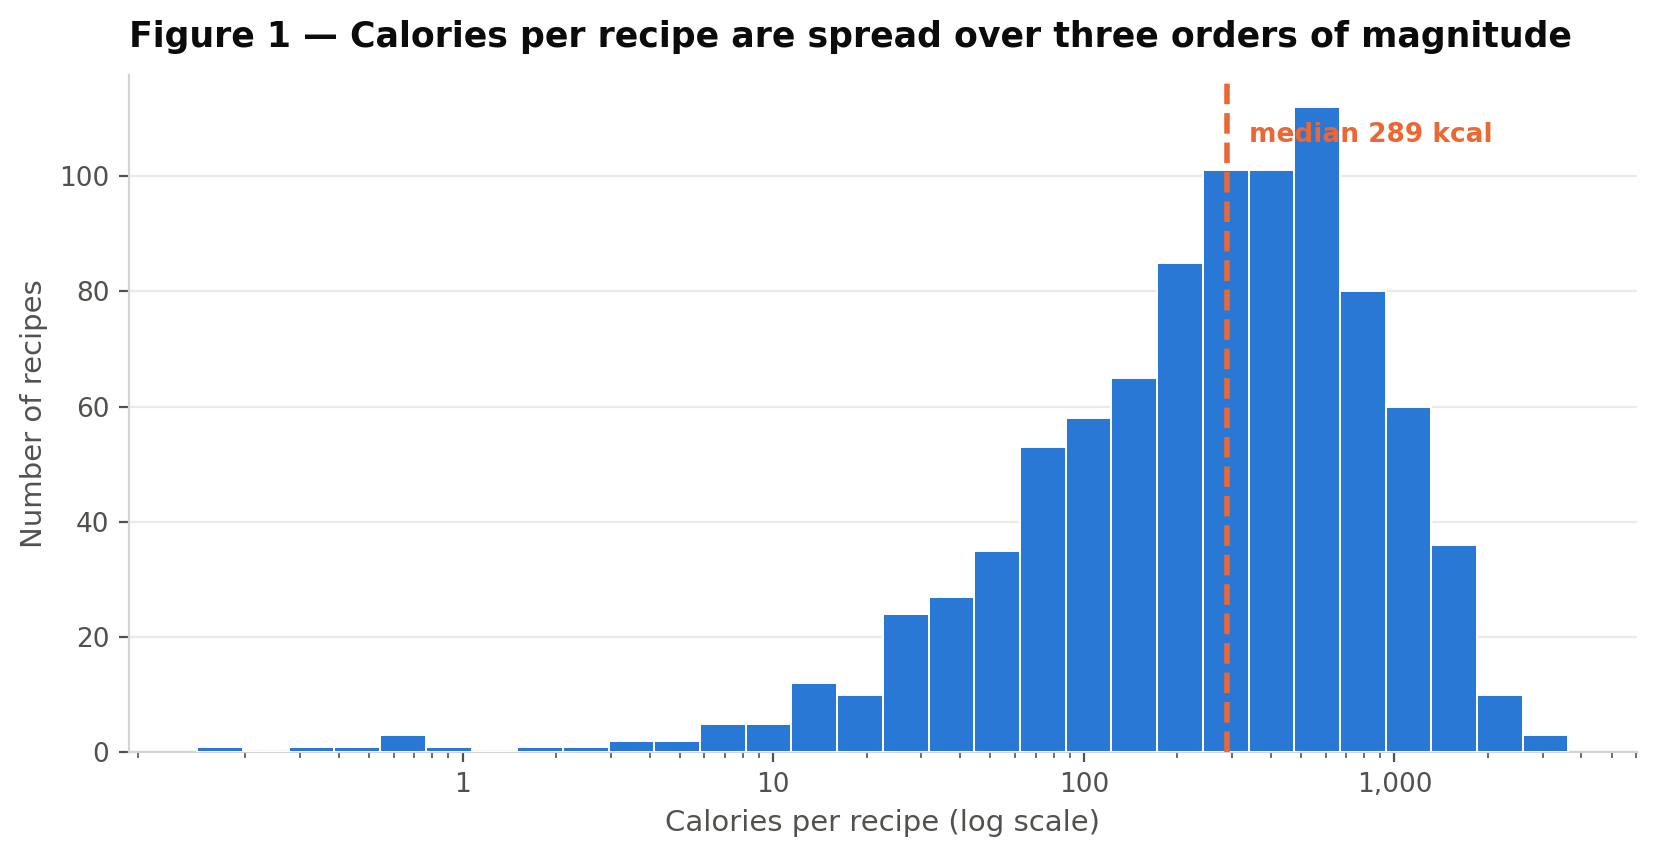

n = 895 recipes with a nutrition panel  |  min 0.14  Q1 110.4  median 288.6  Q3 597.6  max 3,633.16
mean 435.9 is 1.5x the median -> strong right skew


In [10]:
# --- CELL 2.1 --- FIGURE 1: distribution of calories per recipe (single variable, log scale)
cal = clean["calories"].dropna()
bins = np.logspace(np.log10(cal.min()), np.log10(cal.max()), 31)

fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.hist(cal, bins=bins, color=C_BLUE, edgecolor="white", linewidth=0.7, zorder=3)
med = float(cal.median())
ax.axvline(med, color=C_ORANGE, linestyle="--", linewidth=2, zorder=4)
ax.annotate(f"median {med:,.0f} kcal", xy=(med, ax.get_ylim()[1] * 0.93),
            xytext=(8, 0), textcoords="offset points", color=C_ORANGE,
            fontsize=9.5, fontweight="bold", va="top")
ax.set_xscale("log")
ax.set_xticks([1, 10, 100, 1000])
ax.set_xticklabels(["1", "10", "100", "1,000"])
finish(ax, "Figure 1 — Calories per recipe are spread over three orders of magnitude",
       "Calories per recipe (log scale)", "Number of recipes")
fig.tight_layout()
plt.show()

q = cal.quantile([0.25, 0.5, 0.75]).round(1)
keep("Median calories per recipe", med, "2.1", "{:,.0f} kcal", "Exploration")
print(f"n = {len(cal):,} recipes with a nutrition panel  |  min {cal.min():,.2f}  "
      f"Q1 {q[0.25]:,.1f}  median {q[0.5]:,.1f}  Q3 {q[0.75]:,.1f}  max {cal.max():,.2f}")
print(f"mean {cal.mean():,.1f} is {cal.mean() / med:.1f}x the median -> strong right skew")

**What Figure 1 shows.** Calories per recipe run from under one to over three thousand, and the
distribution is heavily right-skewed — the mean sits well above the median. On a log scale the shape is
close to symmetric, i.e. roughly log-normal, with the bulk of recipes between roughly 100 and 600 kcal
and a long tail of large multi-serving dishes.

**Why it matters.** Two practical consequences. First, it confirms the section 1.6 decision: the tail is
a smooth continuation of the distribution, not a cluster of impossible values, so these are real recipes
and should not be capped or removed. Second, it is why the nutrition columns are **standardised** inside
the model pipeline — a linear model would otherwise let a single 3,000-kcal recipe dominate the fit.

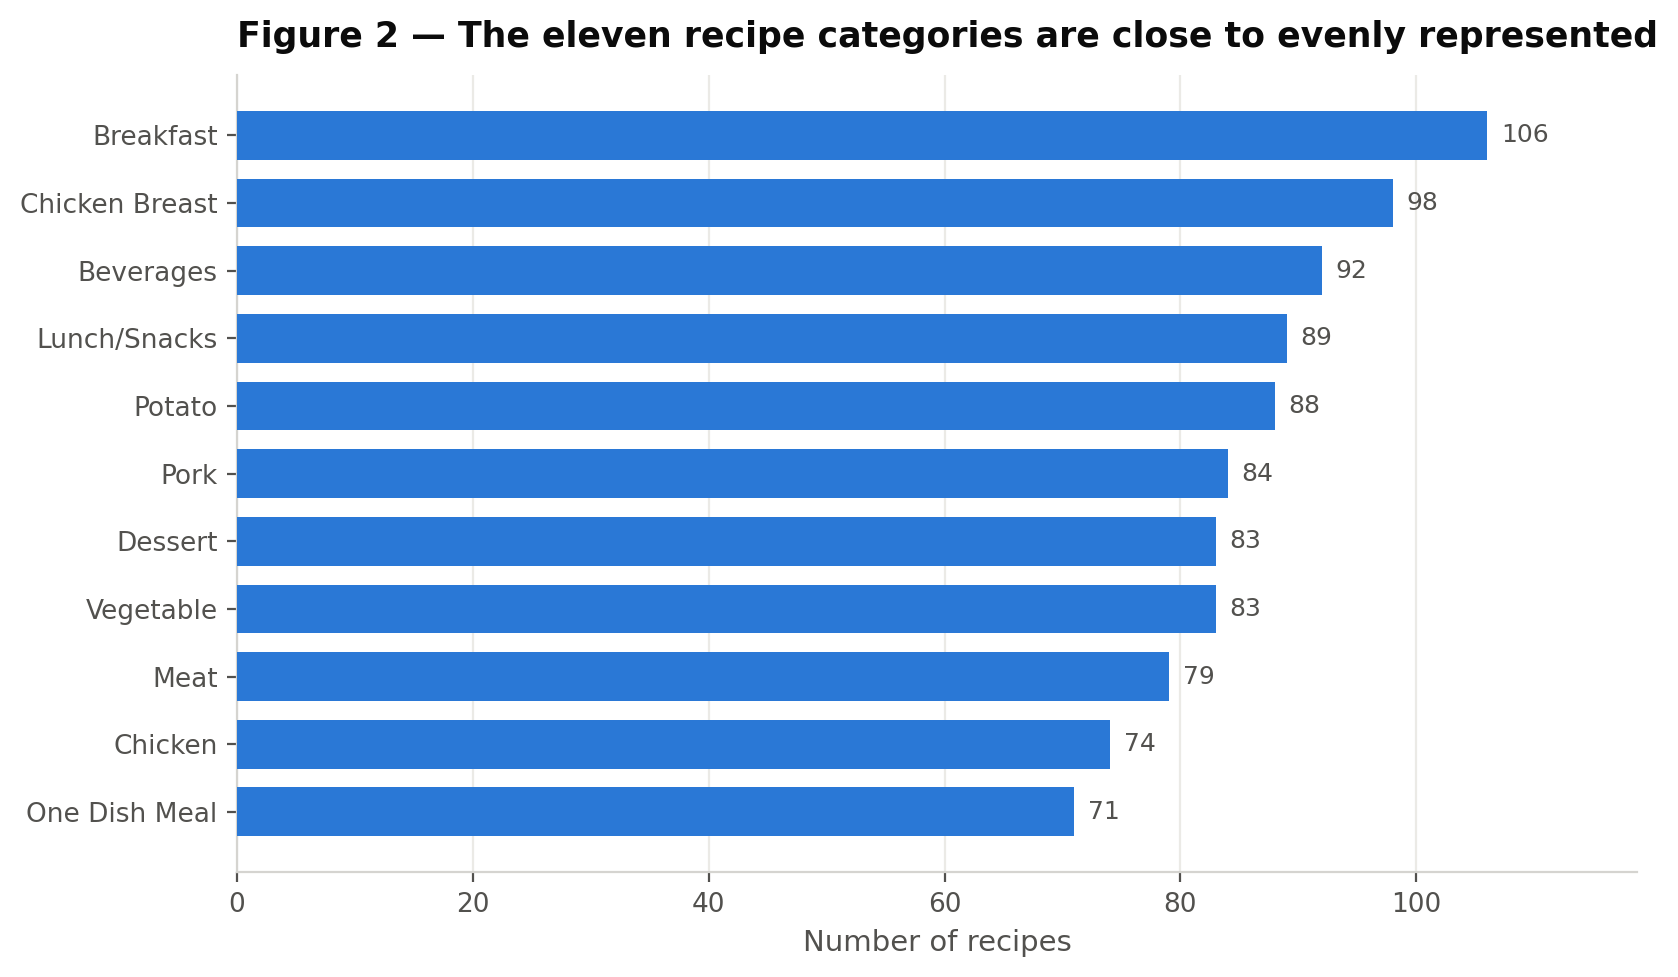

11 categories, 947 recipes
largest  : Breakfast (106 recipes, 11.2%)
smallest : One Dish Meal (71 recipes, 7.5%)


In [11]:
# --- CELL 2.2 --- FIGURE 2: number of recipes per category (single variable, second chart type)
counts = clean["category"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.barh(counts.index, counts.values, color=C_BLUE, height=0.72, zorder=3)
for name, v in counts.items():
    ax.annotate(f"{v}", xy=(v, name), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, counts.max() * 1.12)
finish(ax, "Figure 2 — The eleven recipe categories are close to evenly represented",
       "Number of recipes", None, grid_axis="x")
fig.tight_layout()
plt.show()

print(f"{clean['category'].nunique()} categories, {counts.sum():,} recipes")
print(f"largest  : {counts.idxmax()} ({counts.max()} recipes, {counts.max()/counts.sum():.1%})")
print(f"smallest : {counts.idxmin()} ({counts.min()} recipes, {counts.min()/counts.sum():.1%})")
keep("Smallest category size", int(counts.min()), "2.2", "{:,} recipes", "Exploration")

**What Figure 2 shows.** The eleven categories are close to balanced: from 71 recipes (`One Dish Meal`)
to 106 (`Breakfast`). No category dominates the dataset and none is so rare that a rate computed on it
would be meaningless.

**Why it matters.** It makes the per-category comparison in Figure 3 trustworthy — every bar there rests
on at least 71 recipes, so the differences we are about to see are not the artefact of a thin slice.
It also means one-hot encoding `category` is safe: eleven dummy columns on 947 rows is a comfortable
ratio, and no level needs to be collapsed for sparsity reasons. This is the chart that makes the
decision to keep `Chicken Breast` separate (98 recipes of its own) defensible.

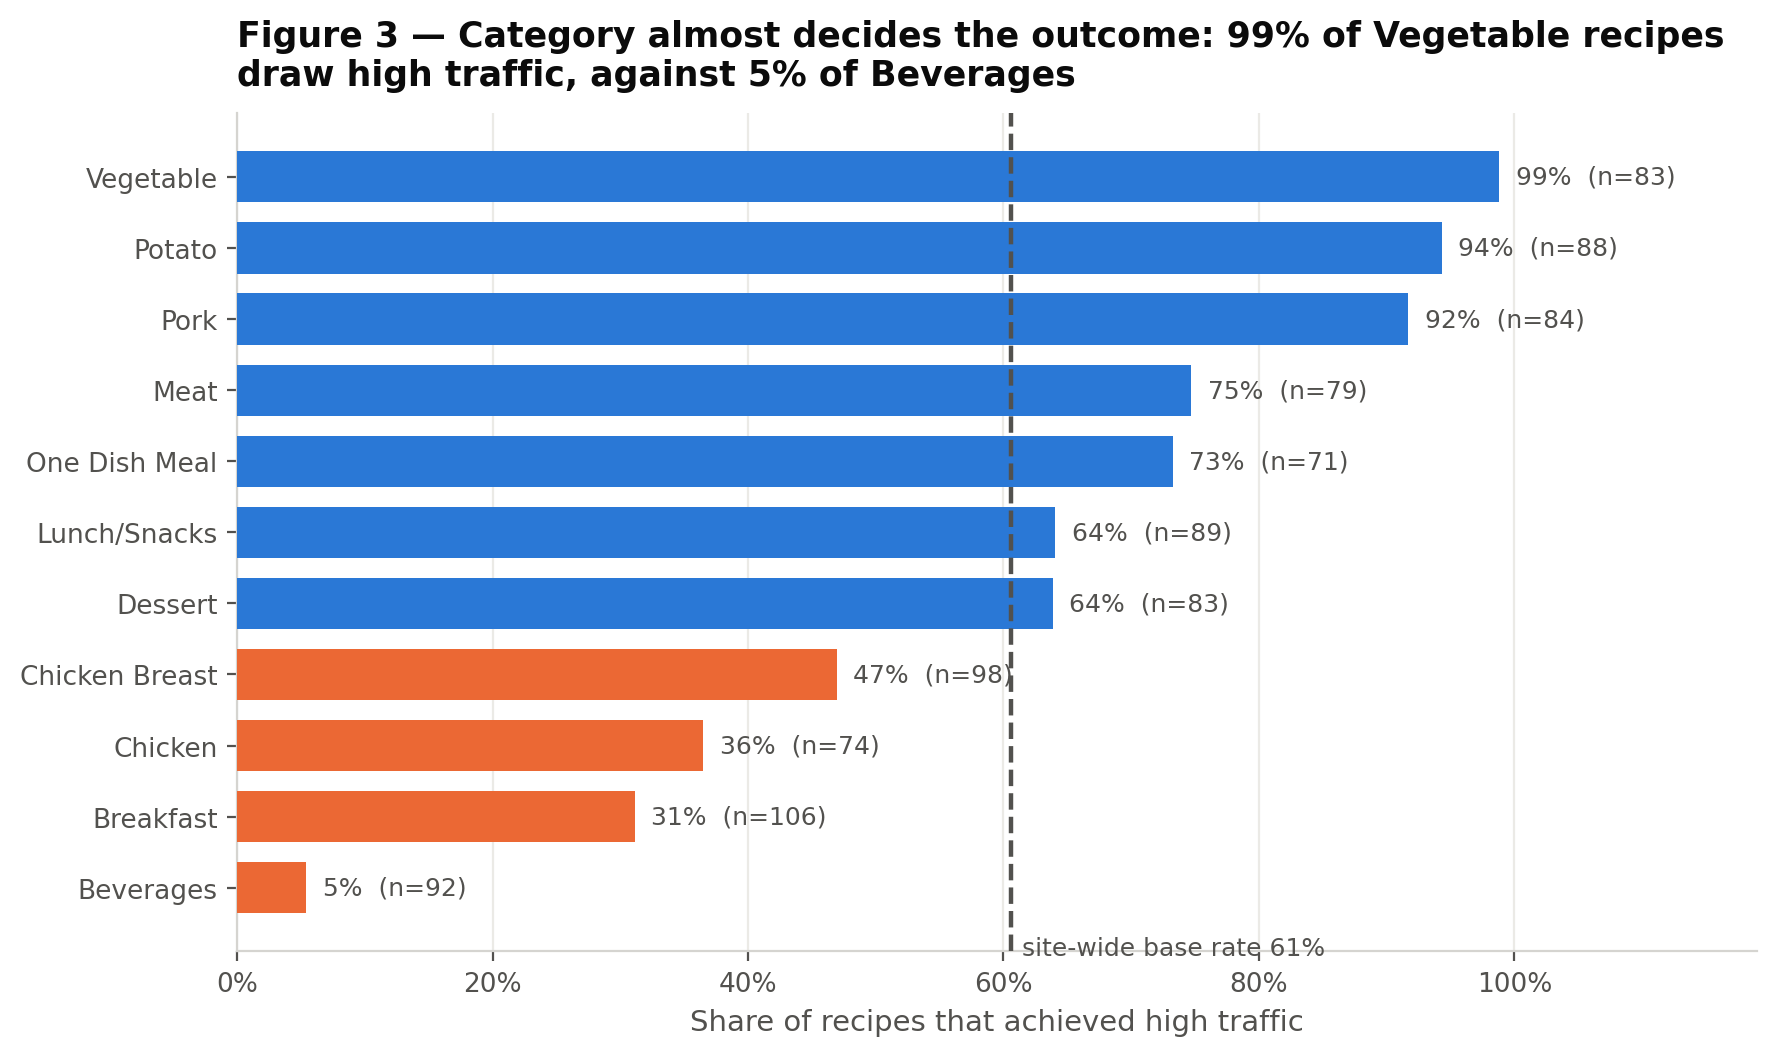

                recipes  high high_rate
category                               
Beverages            92     5      5.4%
Breakfast           106    33     31.1%
Chicken              74    27     36.5%
Chicken Breast       98    46     46.9%
Dessert              83    53     63.9%
Lunch/Snacks         89    57     64.0%
One Dish Meal        71    52     73.2%
Meat                 79    59     74.7%
Pork                 84    77     91.7%
Potato               88    83     94.3%
Vegetable            83    82     98.8%


In [12]:
# --- CELL 2.3 --- FIGURE 3: high-traffic rate by category (two variables) - the central result
by_cat = (clean.groupby("category")["high_traffic_flag"]
          .agg(recipes="count", high="sum", high_rate="mean")
          .sort_values("high_rate"))

fig, ax = plt.subplots(figsize=(9.0, 5.4))
# Colour carries magnitude, not identity: above the site-wide base rate vs below it.
colors = [C_BLUE if r >= base_rate else C_ORANGE for r in by_cat["high_rate"]]
ax.barh(by_cat.index, by_cat["high_rate"], color=colors, height=0.72, zorder=3)
ax.axvline(base_rate, color=INK_2, linestyle="--", linewidth=1.6, zorder=4)
ax.annotate(f"site-wide base rate {base_rate:.0%}", xy=(base_rate, -0.85),
            xytext=(4, 0), textcoords="offset points", fontsize=9, color=INK_2, va="center")
for name, row in by_cat.iterrows():
    ax.annotate(f"{row['high_rate']:.0%}  (n={int(row['recipes'])})",
                xy=(row["high_rate"], name), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK_2)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlim(0, 1.19)
finish(ax, "Figure 3 — Category almost decides the outcome: 99% of Vegetable recipes\n"
           "draw high traffic, against 5% of Beverages",
       "Share of recipes that achieved high traffic", None, grid_axis="x")
fig.tight_layout()
plt.show()

print(by_cat.assign(high_rate=lambda d: d["high_rate"].map("{:.1%}".format)).to_string())
for name in ["Vegetable", "Potato", "Pork", "Chicken Breast", "Chicken", "Breakfast", "Beverages"]:
    keep(f"High-traffic rate - {name}", float(by_cat.loc[name, "high_rate"]), "2.3", "{:.1%}",
         "Category rates")
keep("Beverages - high-traffic recipes out of the category total",
     f"{int(by_cat.loc['Beverages', 'high'])} of {int(by_cat.loc['Beverages', 'recipes'])}",
     "2.3", None, "Category rates")
keep("Vegetable - high-traffic recipes out of the category total",
     f"{int(by_cat.loc['Vegetable', 'high'])} of {int(by_cat.loc['Vegetable', 'recipes'])}",
     "2.3", None, "Category rates")
keep("Spread in high-traffic rate across categories (pp)",
     float(by_cat["high_rate"].max() - by_cat["high_rate"].min()) * 100, "2.3", "{:.0f} pp",
     "Category rates")
keep("Categories above the site-wide base rate", int((by_cat["high_rate"] >= base_rate).sum()),
     "2.3", "{:,} of 11", "Category rates")

**What Figure 3 shows.** This is the single most important chart in the analysis. The high-traffic rate
is not remotely constant across categories — it runs from **5% for Beverages to 99% for Vegetable**, a
spread of about 93 percentage points around a site-wide average of 61%. Seven categories sit above the
average (`Vegetable`, `Potato`, `Pork`, `Meat`, `One Dish Meal`, `Lunch/Snacks`, `Dessert` — the last
two only barely) and four clearly below (`Chicken Breast`, `Chicken`, `Breakfast`, `Beverages`).

**Why it matters commercially.** Three things follow directly.

1. **The Product Manager's question already has a partial answer that needs no model.** A rule as simple
   as *"feature a Vegetable, Potato or Pork recipe"* would clear the 80% target on this data. The value a
   model adds is ranking *within* those categories and handling the ambiguous middle.
2. **Beverages are close to a guaranteed loss** — 5 high-traffic recipes out of 92. Whatever else the
   recommendation does, it should almost never put a beverage in the homepage slot.
3. **It vindicates keeping `Chicken Breast` separate** from `Chicken` (section 1.3): the two rates differ
   by more than 10 percentage points, so merging them would have blurred a real distinction and made the
   guidance worse.

This chart is also the reason a *linear* model is enough here: most of the signal is a difference in
level between categories, which one-hot encoding plus logistic regression captures exactly.

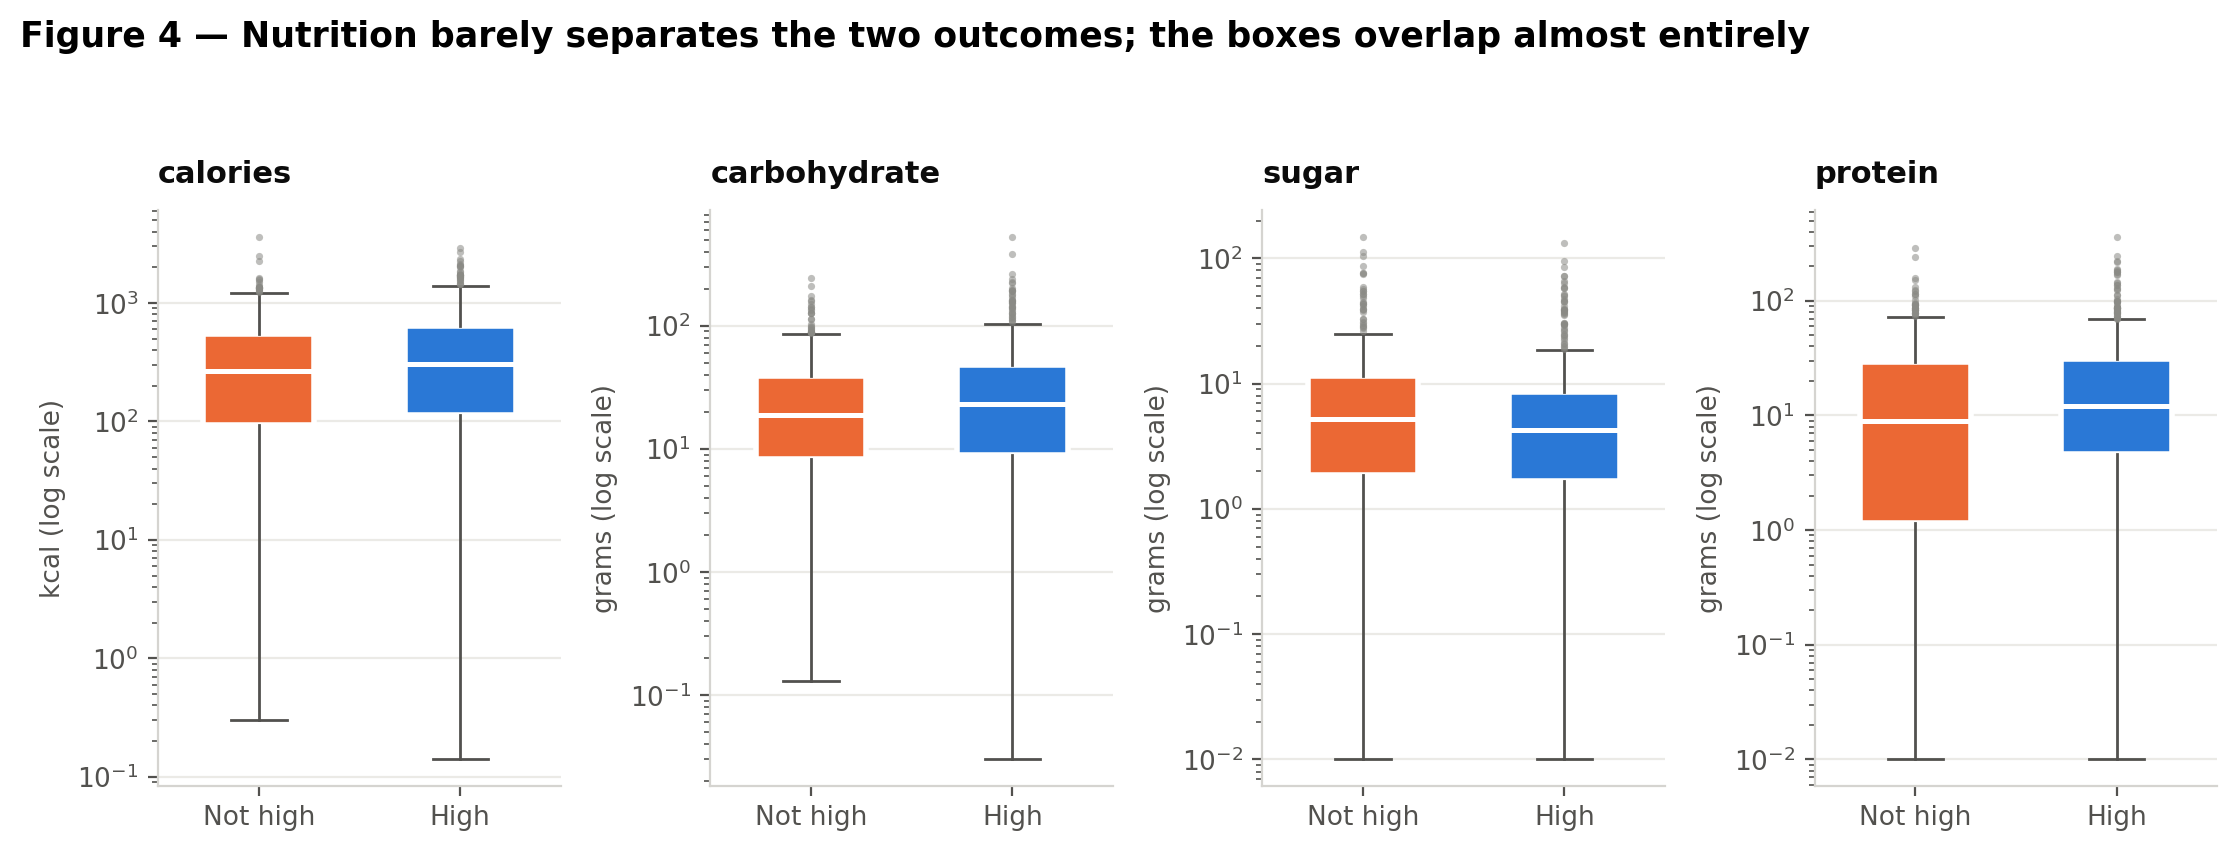

Values excluded from the log axes (non-positive): {'calories': 0, 'carbohydrate': 0, 'sugar': 0, 'protein': 2}  -> the two protein zeros only

high_traffic_flag  median | Not high  median | High  ratio High / Not high
calories                      267.77         305.09                   1.14
carbohydrate                   18.84          23.16                   1.23
sugar                           5.18           4.25                   0.82
protein                         8.78          12.03                   1.37

Rank correlation of each nutrient with the outcome (Spearman):
calories        0.069
carbohydrate    0.065
sugar          -0.071
protein         0.119


In [13]:
# --- CELL 2.4 --- FIGURE 4: nutrition profile by outcome (two variables, log scale)
fig, axes = plt.subplots(1, 4, figsize=(11.2, 4.3))
dropped = {}
for ax, col in zip(axes, NUTRIENTS):
    groups, labs = [], ["Not high", "High"]
    for flag in (0, 1):
        v = clean.loc[clean["high_traffic_flag"] == flag, col].dropna()
        dropped[col] = dropped.get(col, 0) + int((v <= 0).sum())   # log scale needs v > 0
        groups.append(v[v > 0].values)
    bp = ax.boxplot(groups, patch_artist=True, widths=0.55,
                    medianprops=dict(color="white", linewidth=1.8),
                    flierprops=dict(marker="o", markersize=2.6, markerfacecolor=C_GRAY,
                                    markeredgecolor="none", alpha=0.55),
                    whiskerprops=dict(color=INK_2), capprops=dict(color=INK_2))
    for patch, c in zip(bp["boxes"], [C_ORANGE, C_BLUE]):
        patch.set_facecolor(c)
        patch.set_edgecolor("white")
        patch.set_linewidth(2)          # 2px surface gap between adjacent fills
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labs)
    ax.set_yscale("log")
    ax.grid(True, axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(col, loc="left", fontsize=11)
    ax.set_ylabel("grams (log scale)" if col != "calories" else "kcal (log scale)", fontsize=9.5)
fig.suptitle("Figure 4 — Nutrition barely separates the two outcomes; the boxes overlap almost entirely",
             x=0.005, ha="left", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

print(f"Values excluded from the log axes (non-positive): {dropped}  "
      "-> the two protein zeros only\n")
stats = (clean.groupby("high_traffic_flag")[NUTRIENTS].median().T
         .rename(columns={0: "median | Not high", 1: "median | High"}))
stats["ratio High / Not high"] = (stats["median | High"] / stats["median | Not high"]).round(2)
print(stats.round(2).to_string())
print("\nRank correlation of each nutrient with the outcome (Spearman):")
print(clean[NUTRIENTS + ["high_traffic_flag"]].corr(method="spearman")["high_traffic_flag"]
      .drop("high_traffic_flag").round(3).to_string())
keep("Strongest single nutrient rank-correlation with high traffic",
     float(clean[NUTRIENTS + ["high_traffic_flag"]].corr(method="spearman")["high_traffic_flag"]
           .drop("high_traffic_flag").abs().max()), "2.4", "{:.3f}", "Exploration")

**What Figure 4 shows.** Very little. For all four nutrients the two boxes sit almost on top of each
other: the median high-traffic recipe has a slightly higher protein and carbohydrate content, but the
interquartile ranges overlap almost completely and the rank correlations with the outcome are all
weak (|ρ| ≈ 0.1 or below). Note that the two `protein = 0` recipes are excluded from the log panel only
— they remain in the dataset and in the model.

**Why it matters.** A negative result worth stating plainly: **nutrition alone cannot answer the Product
Manager's question.** It is not useless — the model below gives the nutrients small positive
coefficients, and they help break ties within a category — but anyone hoping that "healthy recipes get
more traffic" would be over-reading this data. The predictive work is being done by category, which is
also the more actionable variable: the Product Manager chooses what kind of recipe to feature far more
easily than its exact protein content.

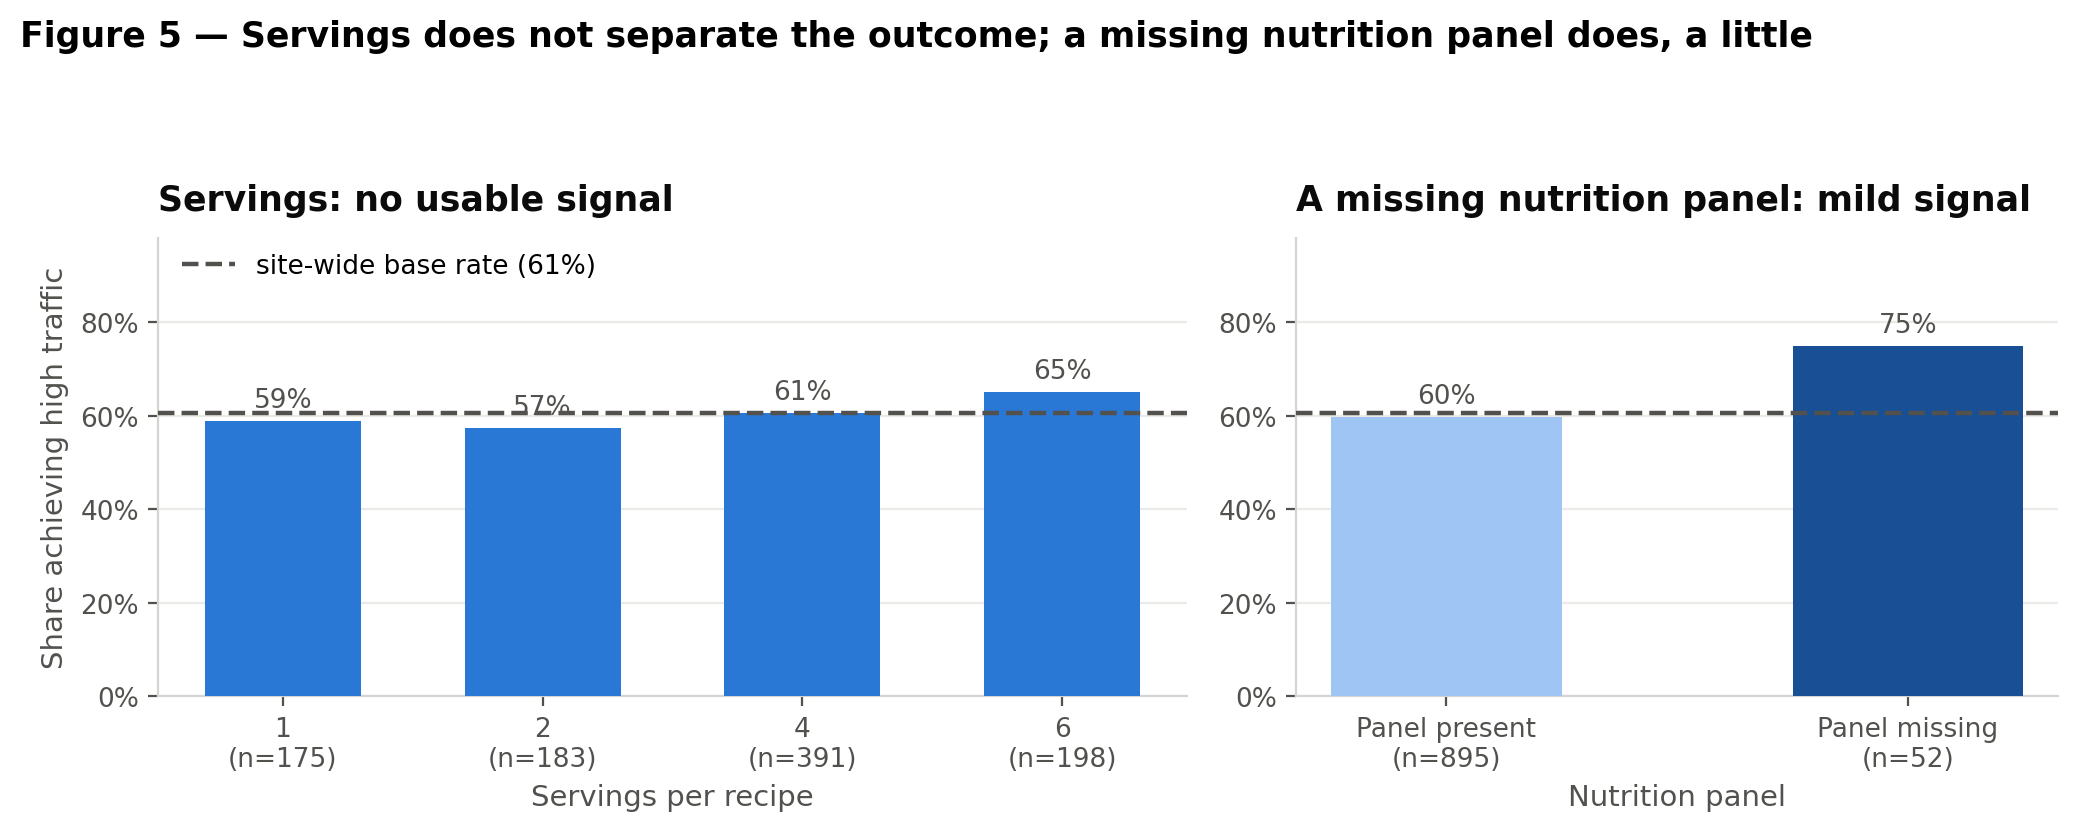

High-traffic rate by servings:
          recipes high_rate
servings                   
1             175     58.9%
2             183     57.4%
4             391     60.6%
6             198     65.2%
chi-square test of independence: chi2 = 2.74, dof = 3, p = 0.434 -> no evidence of an association

High-traffic rate by nutrition_missing:
                   recipes high_rate
nutrition_missing                   
0                      895     59.8%
1                       52     75.0%
chi-square test of independence: chi2 = 4.15, dof = 1, p = 0.042


In [14]:
# --- CELL 2.5 --- FIGURE 5: servings and the missing nutrition panel (two variables each)
import scipy.stats as st

by_srv = (clean.groupby("servings")["high_traffic_flag"]
          .agg(recipes="count", high_rate="mean"))
by_miss = (clean.groupby("nutrition_missing")["high_traffic_flag"]
           .agg(recipes="count", high_rate="mean"))

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
labels = [f"{s}\n(n={int(r)})" for s, r in zip(by_srv.index, by_srv["recipes"])]
ax.bar(labels, by_srv["high_rate"], color=C_BLUE, width=0.6, zorder=3)
ax.axhline(base_rate, color=INK_2, linestyle="--", linewidth=1.6, zorder=4,
           label=f"site-wide base rate ({base_rate:.0%})")
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.02))
for x, (s, row) in enumerate(by_srv.iterrows()):
    ax.annotate(f"{row['high_rate']:.0%}", xy=(x, row["high_rate"]), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=9.5, color=INK_2)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0, 0.98)
finish(ax, "Servings: no usable signal", "Servings per recipe", "Share achieving high traffic")

ax = axes[1]
ax.bar([f"Panel present\n(n={int(by_miss.loc[0, 'recipes'])})",
        f"Panel missing\n(n={int(by_miss.loc[1, 'recipes'])})"], by_miss["high_rate"],
       color=[C_BLUE_LT, C_BLUE_DK], width=0.5, zorder=3)
for x, (s, row) in enumerate(by_miss.iterrows()):
    ax.annotate(f"{row['high_rate']:.0%}", xy=(x, row["high_rate"]), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=9.5, color=INK_2)
ax.axhline(base_rate, color=INK_2, linestyle="--", linewidth=1.6, zorder=4)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0, 0.98)
finish(ax, "A missing nutrition panel: mild signal", "Nutrition panel", None)

fig.suptitle("Figure 5 — Servings does not separate the outcome; a missing nutrition panel does, a little",
             x=0.005, ha="left", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

print("High-traffic rate by servings:")
print(by_srv.assign(high_rate=lambda d: d["high_rate"].map("{:.1%}".format)).to_string())
chi2_s, p_s, dof_s, _ = st.chi2_contingency(
    pd.crosstab(clean["servings"], clean["high_traffic_flag"]))
print(f"chi-square test of independence: chi2 = {chi2_s:.2f}, dof = {dof_s}, p = {p_s:.3f} "
      f"-> {'no' if p_s > 0.05 else 'some'} evidence of an association")

print("\nHigh-traffic rate by nutrition_missing:")
print(by_miss.assign(high_rate=lambda d: d["high_rate"].map("{:.1%}".format)).to_string())
chi2_m, p_m, dof_m, _ = st.chi2_contingency(
    pd.crosstab(clean["nutrition_missing"], clean["high_traffic_flag"]))
print(f"chi-square test of independence: chi2 = {chi2_m:.2f}, dof = {dof_m}, p = {p_m:.3f}")

keep("High-traffic rate, servings spread (min-max)",
     f"{by_srv['high_rate'].min():.1%} to {by_srv['high_rate'].max():.1%}", "2.5", None,
     "Exploration")
keep("Servings chi-square p-value", float(p_s), "2.5", "{:.3f}", "Exploration")
keep("High-traffic rate when the nutrition panel is missing",
     float(by_miss.loc[1, "high_rate"]), "2.5", "{:.1%}", "Exploration")
keep("High-traffic rate when the nutrition panel is present",
     float(by_miss.loc[0, "high_rate"]), "2.5", "{:.1%}", "Exploration")

**What Figure 5 shows.**

- **`servings` is flat.** The high-traffic rate moves between 57.4% and 65.2% across 1, 2, 4 and 6
  servings, with no trend and a chi-square test that finds no evidence of association
  (χ² = 2.74, p = 0.43). It is kept in the model — it is cheap, it is available at prediction time, and
  dropping a variable on the basis of a single marginal test would be premature — but the coefficient in
  cell 4.6 confirms it contributes almost nothing.
- **A missing nutrition panel is mildly informative.** Recipes with no nutrition panel achieve high
  traffic **75.0%** of the time, against **59.8%** for the rest — a gap of about 15 percentage points,
  just about significant on only 52 recipes (χ² = 4.15, p = 0.04). Suggestive rather than conclusive,
  then, but it points the same way as the section 1.2 decision: the missingness itself is data, so it is
  retained as a feature rather than imputed away. A plausible mechanism — worth checking with the
  product team — is that these are older or manually-created recipes that were promoted for other
  reasons.

**Why it matters.** Together with Figure 4 this narrows the story considerably: of the seven candidate
features, one (`category`) carries most of the signal, one (`nutrition_missing`) carries a little, four
(the nutrients) carry small amounts, and one (`servings`) carries essentially none. That is a strong
argument for a **simple, interpretable model** — there is not enough structure here to justify anything
elaborate, and a simple model is one the Product Manager can be told the reasons behind.

### Section 2 conclusion — findings

1. **Category is the dominant predictor.** High-traffic rates range from 5% (`Beverages`) to 99%
   (`Vegetable`). This is the actionable finding, and it is enough on its own to make the 80% target
   look reachable.
2. **Nutrition is weakly predictive at best.** All four nutrients overlap heavily between the two
   outcomes (|ρ| ≤ 0.1). They can refine a ranking within a category; they cannot drive it.
3. **`servings` carries no usable signal** (57.4–65.2%, p = 0.43), and the model confirms this.
4. **A missing nutrition panel is mildly positive** (75.0% vs 59.8%, p = 0.04) — kept as a feature
   rather than imputed away.
5. **The distributions are heavily skewed but coherent.** No value looks like a data-entry error, which
   is why outliers were kept and log scales used instead.
6. **The current, human process achieves high traffic 60.6% of the time.** That is the benchmark any
   model has to beat, and it is the number the 80% target should be compared against.

---
# 3. Model development

## 3.1 What type of problem is this?

This is a **supervised binary classification** problem. Each recipe has a labelled outcome — high
traffic (1) or not (0) — and the task is to predict that label for recipes that have not been featured
yet, from features known *before* the recipe goes on the homepage (its category, its nutrition panel,
its serving count).

Two refinements matter for how the model is actually used:

- What the Product Manager needs is not a hard yes/no on each recipe but a **ranking of the candidate
  pool** — there is one slot per day, so the useful output is a *probability* of high traffic, which lets
  the pool be sorted and the best candidate featured. Both models below therefore produce calibrated-ish
  probabilities, and the decision rule (the threshold) is treated as a separate, tunable business
  choice in section 4.3.
- The classes are only mildly imbalanced (60.6% / 39.4%), so no resampling or class weighting is used.
  Rebalancing would distort the predicted probabilities, which are the very thing the ranking depends on.

## 3.2 Features, and the split

| Feature | Type | Treatment in the pipeline |
|---|---|---|
| `calories`, `carbohydrate`, `sugar`, `protein` | numeric | category-median imputation → standardisation |
| `servings` | numeric (1–6) | standardisation |
| `nutrition_missing` | binary flag | passed through unchanged (already 0/1) |
| `category` | categorical, 11 levels | one-hot encoded, all levels retained |

`recipe` is excluded (section 1.1). The split is **stratified**, `test_size = 0.25`,
`random_state = 42`: stratification keeps the 60.6% base rate identical in both halves, which matters
because that base rate is the benchmark the model is judged against; 25% leaves 237 test recipes, enough
to estimate a precision to within roughly ±7 points and small enough to leave 710 rows for training.

In [15]:
# --- CELL 3.1 --- Features, target, stratified train/test split
FEATURES = NUTRIENTS + ["servings", "nutrition_missing", "category"]
NUMERIC_FEATURES = NUTRIENTS + ["servings"]

X = clean[FEATURES].copy()
y = clean["high_traffic_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

split_tbl = pd.DataFrame({
    "recipes": [len(y_train), len(y_test), len(y)],
    "high traffic": [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
    "base rate": [y_train.mean(), y_test.mean(), y.mean()],
}, index=["train", "test", "all"])
print(split_tbl.assign(**{"base rate": lambda d: d["base rate"].map("{:.2%}".format)}).to_string())
print(f"\nFeatures used ({len(FEATURES)}): {FEATURES}")
print("Excluded: recipe (identifier), high_traffic (raw text form of the target)")

keep("Training recipes", int(len(y_train)), "3.1", "{:,}", "Modelling")
keep("Test recipes", int(len(y_test)), "3.1", "{:,}", "Modelling")
keep("Base rate in the test set", float(y_test.mean()), "3.1", "{:.1%}", "Modelling")
keep("High-traffic recipes in the test set", int(y_test.sum()), "3.1", "{:,}", "Modelling")

       recipes  high traffic base rate
train      710           430    60.56%
test       237           144    60.76%
all        947           574    60.61%

Features used (7): ['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'nutrition_missing', 'category']
Excluded: recipe (identifier), high_traffic (raw text form of the target)


## 3.3 The group-median imputer, and why it lives inside the pipeline

scikit-learn's `SimpleImputer` can fill with a global median but has no built-in group-wise option, so
the category × nutrient median lookup is built explicitly below as a small transformer. Being a
transformer is the whole point:

> **`fit` sees only the training rows.** It builds the median table from them; `transform` then applies
> that same table to whichever rows it is given. When the transformer is the first step of a `Pipeline`,
> scikit-learn refits it on the training portion of **every cross-validation fold** and never on the
> held-out portion — so no test-set or validation-fold information can reach the imputed values, and the
> reported scores are honest estimates of performance on unseen recipes.

A category with no complete training rows would produce a missing median, so the transformer falls back
to the **global training median** in that case. It does not arise with this split, but a fold of a
smaller dataset could hit it, and a silent `NaN` reaching the model would be far worse than a slightly
cruder fill.

In [16]:
# --- CELL 3.2 --- A group-median imputer that learns only from the data it is fitted on
class CategoryMedianImputer(BaseEstimator, TransformerMixin):
    '''Fill the nutrition columns with the median of the recipe's own category.

    The category x nutrient median table is learned in `fit` (training rows only) and merely
    applied in `transform`, so placing this first in a Pipeline makes the imputation
    leak-free under cross-validation as well as on the held-out test set. Falls back to the
    global training median for any category that had no complete rows at fit time.
    '''

    def __init__(self, group_col="category", target_cols=None):
        self.group_col = group_col
        self.target_cols = target_cols

    def fit(self, X, y=None):
        cols = self.target_cols if self.target_cols is not None else list(X.columns)
        self.target_cols_ = cols
        self.medians_ = X.groupby(self.group_col)[cols].median()      # per-category medians
        self.global_medians_ = X[cols].median()                        # fallback
        self.n_fit_rows_ = len(X)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.target_cols_:
            fill = X[self.group_col].map(self.medians_[col]).fillna(self.global_medians_[col])
            X[col] = X[col].fillna(fill)
        return X


# Inspect the table the imputer learns from the training split (for the report only - the
# pipeline refits it internally).
_imp = CategoryMedianImputer(target_cols=NUTRIENTS).fit(X_train)
print(f"Median lookup table learned from the {_imp.n_fit_rows_} TRAINING rows only:\n")
print(_imp.medians_.round(2).to_string())
print(f"\nGlobal training fallback medians: {_imp.global_medians_.round(2).to_dict()}")
print(f"Categories with no complete training rows (needing the fallback): "
      f"{int(_imp.medians_.isna().any(axis=1).sum())}")

_check = _imp.transform(X_train)
print(f"\nMissing nutrition values in train: {int(X_train[NUTRIENTS].isna().sum().sum())} "
      f"before -> {int(_check[NUTRIENTS].isna().sum().sum())} after imputation")

Median lookup table learned from the 710 TRAINING rows only:

                calories  carbohydrate  sugar  protein
category                                              
Beverages         126.96         12.78   8.59     0.43
Breakfast         200.73         28.03   4.97    11.82
Chicken           375.32         16.61   3.99    24.10
Chicken Breast    360.33         13.54   4.30    38.44
Dessert           264.90         35.62  27.03     4.74
Lunch/Snacks      369.50         33.06   2.68    14.16
Meat              394.16         19.74   4.51    27.70
One Dish Meal     403.43         26.05   3.88    26.62
Pork              388.44         19.16   5.23    32.23
Potato            268.03         31.84   2.56     5.81
Vegetable         146.40         12.48   3.45     4.10

Global training fallback medians: {'calories': 294.49, 'carbohydrate': 21.5, 'sugar': 4.55, 'protein': 11.58}
Categories with no complete training rows (needing the fallback): 0

Missing nutrition values in train: 168 befo

## 3.4 Baseline model — logistic regression

**Why this as the baseline:** because the Product Manager has to act on the output, and logistic
regression is the model that can explain itself. Every prediction decomposes into one coefficient per
category plus small nutrition adjustments, so the answer to *"why is this recipe predicted popular?"* is
a sentence, not a shrug. Section 2 also showed that most of the signal is a difference in *level*
between categories, which one-hot encoding plus a linear model captures exactly — there is little
non-linear structure for a more flexible model to find.

Defaults are used deliberately (`lbfgs`, L2 penalty, `C = 1.0`): with 947 rows and 16 encoded features
there is no case for an aggressive search, and leaving the regularisation at its default keeps the
coefficients readable. `max_iter` is raised to 2000 purely so the solver converges.

## 3.5 Comparison model — random forest

**Why this as the comparison:** it is the natural opposite of the baseline. It is non-linear, it finds
interactions between category and nutrition without being told to look for them, and it is invariant to
the monotone skew that made the log scales necessary in section 2. If a linear model were leaving
structure on the table, the forest would show it as a higher ROC-AUC.

`min_samples_leaf = 3` is set to stop the forest carving 947 rows into single-recipe leaves;
`n_estimators = 500` makes the predicted probabilities stable enough to threshold. Both models sit in
the **same pipeline**, so they see exactly the same imputation, scaling and encoding, and the comparison
is about the algorithm rather than about the preprocessing.

In [17]:
# --- CELL 3.3 --- One pipeline definition shared by both models
def build_pipeline(estimator):
    '''Imputation -> scaling / one-hot encoding -> estimator, as a single fitted object.

    Everything that learns from data sits inside, so nothing is fitted on held-out rows.
    '''
    preprocess = ColumnTransformer(
        transformers=[
            # Standardise the numerics: the nutrition columns differ by orders of magnitude
            # (cell 2.1) and a linear model would otherwise be dominated by calories.
            ("num", StandardScaler(), NUMERIC_FEATURES),
            # Already 0/1 - scaling it would only make the coefficient harder to read.
            ("flag", "passthrough", ["nutrition_missing"]),
            # All 11 levels kept; handle_unknown="ignore" means a future new category
            # scores from the intercept and nutrition instead of raising.
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["category"]),
        ],
        remainder="drop", verbose_feature_names_out=True)

    return Pipeline([
        ("impute", CategoryMedianImputer(target_cols=NUTRIENTS)),
        ("preprocess", preprocess),
        ("model", estimator),
    ])


logreg = build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
forest = build_pipeline(RandomForestClassifier(
    n_estimators=500, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))

MODELS = {"Logistic regression (baseline)": logreg, "Random forest (comparison)": forest}
logreg

Pipeline(steps=[('impute',
                 CategoryMedianImputer(target_cols=['calories', 'carbohydrate',
                                                    'sugar', 'protein'])),
                ('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['calories', 'carbohydrate',
                                                   'sugar', 'protein',
                                                   'servings']),
                                                 ('flag', 'passthrough',
                                                  ['nutrition_missing']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['category'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [18]:
# --- CELL 3.4 --- Cross-validated fit on the training split, then fit on all training rows
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, pipe in MODELS.items():
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    ap = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision")
    cv_rows.append({"model": name, "CV ROC-AUC": auc.mean(), "CV ROC-AUC sd": auc.std(),
                    "CV avg precision": ap.mean()})
    pipe.fit(X_train, y_train)          # refit on the full training split for test evaluation

cv_tbl = pd.DataFrame(cv_rows).set_index("model")
print("5-fold stratified cross-validation on the TRAINING split "
      "(preprocessing refitted inside every fold):\n")
print(cv_tbl.round(4).to_string())
print("\nBoth models are now fitted on all 710 training rows and are ready for evaluation.")
keep("Logistic regression CV ROC-AUC (train)", float(cv_tbl.loc["Logistic regression (baseline)",
     "CV ROC-AUC"]), "3.4", "{:.3f}", "Modelling")
keep("Random forest CV ROC-AUC (train)", float(cv_tbl.loc["Random forest (comparison)",
     "CV ROC-AUC"]), "3.4", "{:.3f}", "Modelling")

5-fold stratified cross-validation on the TRAINING split (preprocessing refitted inside every fold):

                                CV ROC-AUC  CV ROC-AUC sd  CV avg precision
model                                                                      
Logistic regression (baseline)      0.8115         0.0169            0.8604
Random forest (comparison)          0.8038         0.0107            0.8595

Both models are now fitted on all 710 training rows and are ready for evaluation.


---
# 4. Model evaluation

## 4.1 How the two models compare

The table below evaluates both models on the **held-out 237 test recipes**, which neither model — and
neither model's imputer, scaler or encoder — has seen. Metrics are reported at the default 0.5 threshold
first, so the two algorithms are compared on equal terms before the threshold is tuned.

The column that matters is **precision (High)**: of the recipes the model recommends, the share that
actually achieved high traffic. Recall, F1 and accuracy are shown for completeness, and ROC-AUC and
average precision summarise the ranking quality across all thresholds, which is what the daily
ranking use-case actually depends on.

In [19]:
# --- CELL 4.1 --- Test-set comparison of both models at the default 0.5 threshold
proba = {name: pipe.predict_proba(X_test)[:, 1] for name, pipe in MODELS.items()}

rows = []
for name, p in proba.items():
    pred = (p >= 0.5).astype(int)
    rows.append({
        "model": name,
        "precision (High)": precision_score(y_test, pred),
        "recall (High)": recall_score(y_test, pred),
        "F1 (High)": f1_score(y_test, pred),
        "accuracy": accuracy_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, p),
        "avg precision": average_precision_score(y_test, p),
        "recipes recommended": int(pred.sum()),
    })
comparison = pd.DataFrame(rows).set_index("model")

print("TEST SET (237 recipes), decision threshold 0.5:\n")
print(comparison.round(4).to_string())
print(f"\nFor reference, the current human process achieves {base_rate:.1%} "
      "(the base rate); a model that recommended every recipe would score exactly that on precision.")
print(f"\n{'-' * 78}\nPer-class detail, logistic regression:\n")
print(classification_report(y_test, (proba["Logistic regression (baseline)"] >= 0.5).astype(int),
                            target_names=["Not high", "High"], digits=3))

for name, short in [("Logistic regression (baseline)", "Logistic regression"),
                    ("Random forest (comparison)", "Random forest")]:
    keep(f"{short} - precision (High) at threshold 0.50",
         float(comparison.loc[name, "precision (High)"]), "4.1", "{:.3f}", "Model comparison")
    keep(f"{short} - recall (High) at threshold 0.50",
         float(comparison.loc[name, "recall (High)"]), "4.1", "{:.3f}", "Model comparison")
    keep(f"{short} - F1 (High) at threshold 0.50",
         float(comparison.loc[name, "F1 (High)"]), "4.1", "{:.3f}", "Model comparison")
    keep(f"{short} - accuracy at threshold 0.50",
         float(comparison.loc[name, "accuracy"]), "4.1", "{:.3f}", "Model comparison")
    keep(f"{short} - test ROC-AUC", float(comparison.loc[name, "ROC-AUC"]), "4.1", "{:.3f}",
         "Model comparison")
    keep(f"{short} - test average precision",
         float(comparison.loc[name, "avg precision"]), "4.1", "{:.3f}", "Model comparison")

TEST SET (237 recipes), decision threshold 0.5:



                                precision (High)  recall (High)  F1 (High)  accuracy  ROC-AUC  avg precision  recipes recommended
model                                                                                                                            
Logistic regression (baseline)            0.8308         0.7500     0.7883    0.7553   0.8461         0.9017                  130
Random forest (comparison)                0.8134         0.7569     0.7842    0.7468   0.8198         0.8835                  134

For reference, the current human process achieves 60.6% (the base rate); a model that recommended every recipe would score exactly that on precision.

------------------------------------------------------------------------------
Per-class detail, logistic regression:

              precision    recall  f1-score   support

    Not high      0.664     0.763     0.710        93
        High      0.831     0.750     0.788       144

    accuracy                          0.755 

**Reading the table.** The two models are close, and the simpler one is ahead on every metric that
matters here: the logistic regression has the higher ROC-AUC, the higher average precision and the
higher precision on the High class. The random forest's only lead is a marginally higher recall
(0.757 vs 0.750) — one extra high-traffic recipe caught, at the cost of recommending four more
recipes overall — which is not the metric the business asked for. That is exactly what section 2
predicted — the signal is mostly a difference in level between categories, so
there are no interactions left for the forest to find, and on 710 training rows its additional variance
costs more than its flexibility earns.

Both models already exceed 0.80 precision at the default threshold. Section 4.3 does not treat that as
sufficient, for a reason explained there.

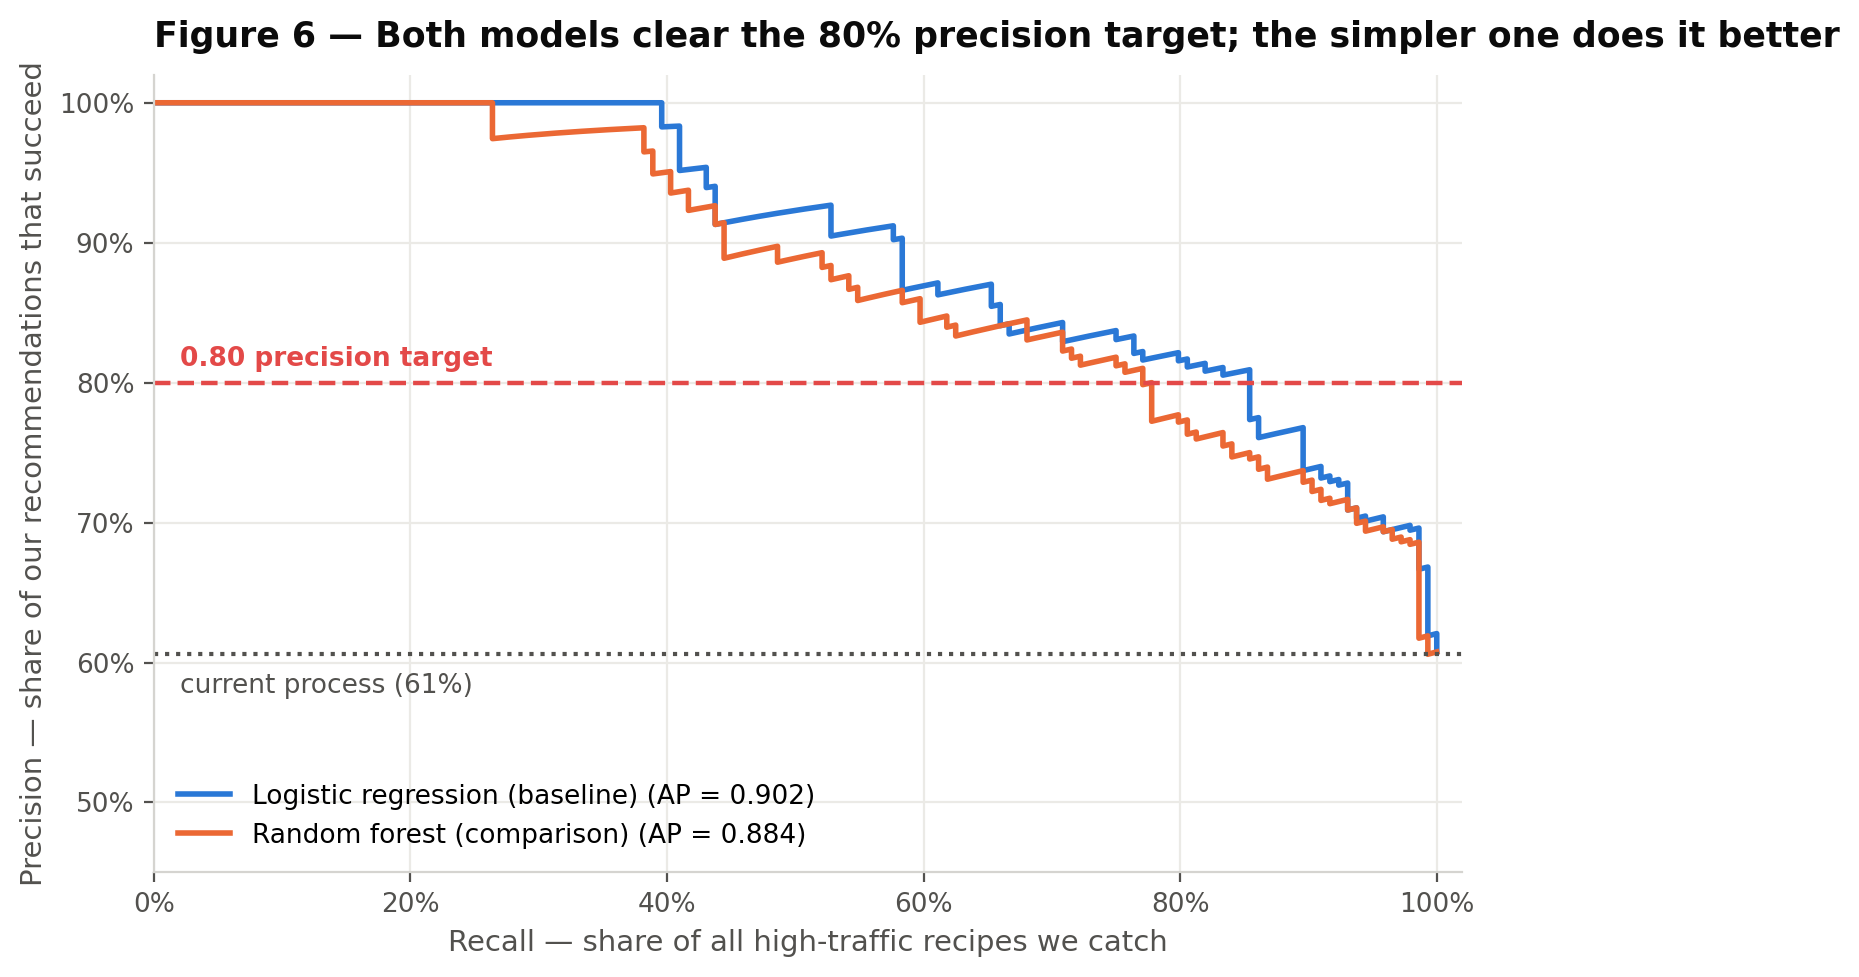

Every point on a curve is one possible decision threshold. Moving left buys precision
by recommending fewer recipes; the whole logistic-regression curve sits above the 80%
line until recall passes roughly 80%, which is what makes the target comfortably reachable.


In [20]:
# --- CELL 4.2 --- FIGURE 6: precision-recall curves for both models
fig, ax = plt.subplots(figsize=(7.6, 5.0))
for (name, p), colour in zip(proba.items(), [C_BLUE, C_ORANGE]):
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax.plot(rec, prec, color=colour, label=f"{name} (AP = {average_precision_score(y_test, p):.3f})")
ax.axhline(0.80, color=C_RED, linestyle="--", linewidth=1.6)
ax.annotate("0.80 precision target", xy=(0.02, 0.80), xytext=(0, 6), textcoords="offset points",
            color=C_RED, fontsize=9.5, fontweight="bold")
ax.axhline(base_rate, color=INK_2, linestyle=":", linewidth=1.5)
ax.annotate(f"current process ({base_rate:.0%})", xy=(0.02, base_rate), xytext=(0, -14),
            textcoords="offset points", color=INK_2, fontsize=9.5)
ax.set_xlim(0, 1.02)
ax.set_ylim(0.45, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(loc="lower left")
finish(ax, "Figure 6 — Both models clear the 80% precision target; the simpler one does it better",
       "Recall — share of all high-traffic recipes we catch",
       "Precision — share of our recommendations that succeed", grid_axis="both")
fig.tight_layout()
plt.show()

print("Every point on a curve is one possible decision threshold. Moving left buys precision")
print("by recommending fewer recipes; the whole logistic-regression curve sits above the 80%")
print("line until recall passes roughly 80%, which is what makes the target comfortably reachable.")

**What Figure 6 shows.** Each curve traces the trade-off available from one model: every point is a
different decision threshold. The logistic-regression curve sits above the 0.80 precision line across
most of its range and above the random forest almost everywhere, and both curves sit far above the 61%
line that the current process achieves. There is no narrow, fragile point at which the target is met —
there is a whole region, which is what makes the result robust rather than a lucky threshold.

## 4.2 Threshold tuning — and why it is not done on the test set

Section 4.1 showed precision above 0.80 at the default threshold of 0.5. That is *not* enough to promise
the Product Manager 80%, for a subtle but important reason: reading a threshold off the test set and then
reporting the test-set precision at that threshold is a form of self-marking. The number would be
optimistically biased and the promise would not hold on new recipes.

So the threshold is chosen on **out-of-fold predictions from the training split only** — each training
recipe scored by a model that did not see it — and then applied, unchanged, to the test set. The rule is
deliberately simple and stated in advance:

> **Choose the lowest threshold whose out-of-fold precision reaches 0.80.**

Lowest, because precision above the target is not worth extra: any further increase costs recall, and
the business requirement is 80%, not the highest number obtainable. The test set is then used exactly
once, as an unbiased check on whether the promise holds.

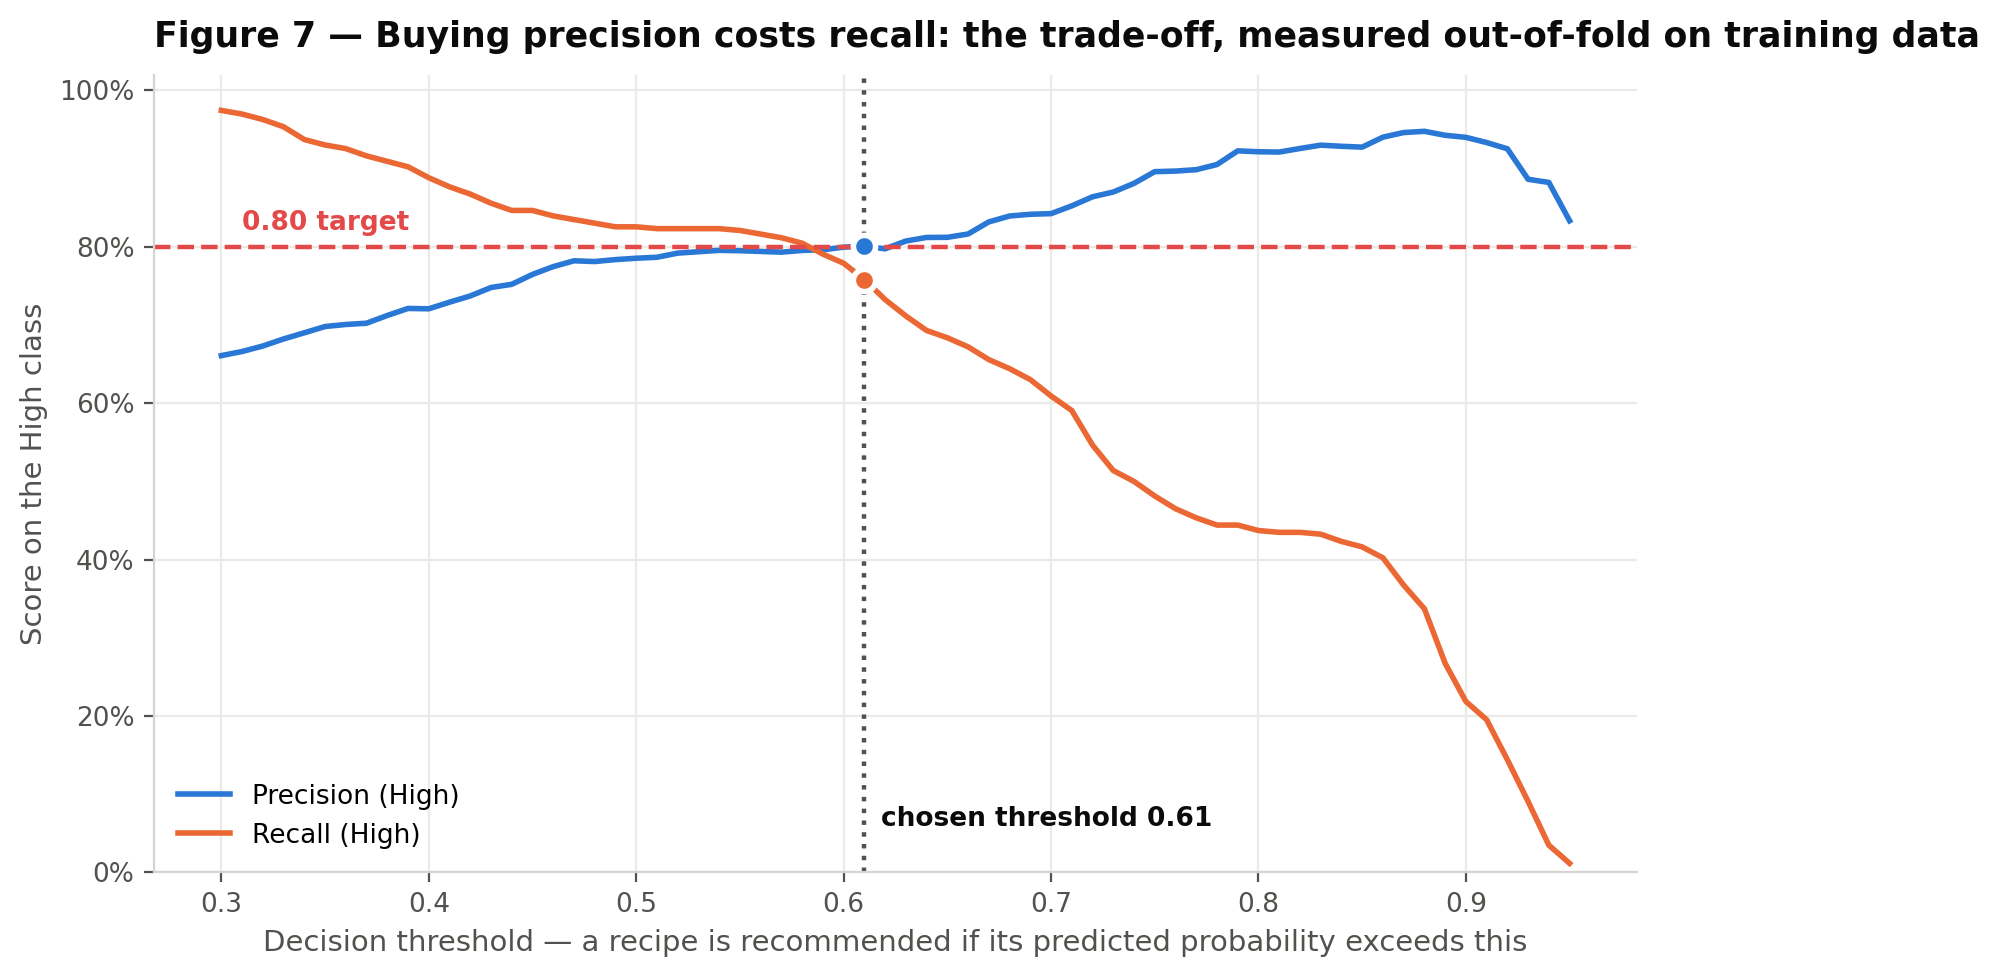

Out-of-fold sweep around the chosen threshold (training split, 5 folds):

 threshold precision recall  recommended
      0.45     0.765  0.847          476
      0.46     0.775  0.840          466
      0.47     0.782  0.835          459
      0.48     0.781  0.830          457
      0.49     0.784  0.826          453
      0.50     0.785  0.826          452
      0.51     0.787  0.823          450
      0.52     0.792  0.823          447
      0.53     0.794  0.823          446
      0.54     0.796  0.823          445
      0.55     0.795  0.821          444
      0.56     0.794  0.816          442
      0.57     0.793  0.812          440
      0.58     0.795  0.805          435
      0.59     0.796  0.791          427
      0.60     0.800  0.779          419
      0.61     0.801  0.758          407
      0.62     0.797  0.733          395
      0.63     0.807  0.712          379
      0.64     0.812  0.693          367
      0.65     0.812  0.684          362
      0.66     0.816  0.

In [21]:
# --- CELL 4.3 --- FIGURE 7: threshold selection on out-of-fold TRAINING predictions
PRECISION_TARGET = 0.80
best_name = "Logistic regression (baseline)"

oof = cross_val_predict(MODELS[best_name], X_train, y_train, cv=cv, method="predict_proba")[:, 1]

grid = np.round(np.arange(0.30, 0.951, 0.01), 2)
sweep = []
for t in grid:
    pred = (oof >= t).astype(int)
    if pred.sum() == 0:
        continue
    sweep.append({"threshold": t,
                  "precision": precision_score(y_train, pred),
                  "recall": recall_score(y_train, pred),
                  "recommended": int(pred.sum())})
sweep = pd.DataFrame(sweep)

meets = sweep[sweep["precision"] >= PRECISION_TARGET]
THRESHOLD = float(meets["threshold"].iloc[0])
chosen_oof = meets.iloc[0]

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.plot(sweep["threshold"], sweep["precision"], color=C_BLUE, label="Precision (High)")
ax.plot(sweep["threshold"], sweep["recall"], color=C_ORANGE, label="Recall (High)")
ax.axhline(PRECISION_TARGET, color=C_RED, linestyle="--", linewidth=1.6)
ax.annotate("0.80 target", xy=(0.31, PRECISION_TARGET), xytext=(0, 6),
            textcoords="offset points", color=C_RED, fontsize=9.5, fontweight="bold")
ax.axvline(THRESHOLD, color=INK_2, linestyle=":", linewidth=1.6)
ax.annotate(f"chosen threshold {THRESHOLD:.2f}", xy=(THRESHOLD, 0.06), xytext=(6, 0),
            textcoords="offset points", color=INK, fontsize=9.5, fontweight="bold")
ax.plot([THRESHOLD], [chosen_oof["precision"]], "o", ms=8, color=C_BLUE,
        markeredgecolor="white", markeredgewidth=2, zorder=5)
ax.plot([THRESHOLD], [chosen_oof["recall"]], "o", ms=8, color=C_ORANGE,
        markeredgecolor="white", markeredgewidth=2, zorder=5)
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(loc="lower left")
finish(ax, "Figure 7 — Buying precision costs recall: the trade-off, measured out-of-fold on training data",
       "Decision threshold — a recipe is recommended if its predicted probability exceeds this",
       "Score on the High class", grid_axis="both")
fig.tight_layout()
plt.show()

print("Out-of-fold sweep around the chosen threshold (training split, 5 folds):\n")
show = sweep[(sweep["threshold"] >= 0.45) & (sweep["threshold"] <= 0.75)].copy()
show["precision"] = show["precision"].map("{:.3f}".format)
show["recall"] = show["recall"].map("{:.3f}".format)
print(show.to_string(index=False))
print(f"\nLowest threshold reaching {PRECISION_TARGET:.0%} out-of-fold precision: {THRESHOLD:.2f}")
print(f"  out-of-fold precision {chosen_oof['precision']:.4f} | "
      f"recall {chosen_oof['recall']:.4f} | recipes recommended {int(chosen_oof['recommended'])} of {len(y_train)}")
print(f"At the default 0.50 threshold the out-of-fold precision is only "
      f"{sweep.loc[sweep['threshold'] == 0.50, 'precision'].iloc[0]:.4f} - below target, which is exactly")
print("why the threshold could not simply be left at its default.")

keep("Chosen decision threshold", THRESHOLD, "4.3", "{:.2f}", "Chosen operating point")
keep("Out-of-fold precision at the chosen threshold", float(chosen_oof["precision"]), "4.3",
     "{:.3f}", "Chosen operating point")
keep("Out-of-fold recall at the chosen threshold", float(chosen_oof["recall"]), "4.3", "{:.3f}",
     "Chosen operating point")
keep("Out-of-fold precision at the default 0.50 threshold",
     float(sweep.loc[sweep["threshold"] == 0.50, "precision"].iloc[0]), "4.3", "{:.3f}",
     "Chosen operating point")

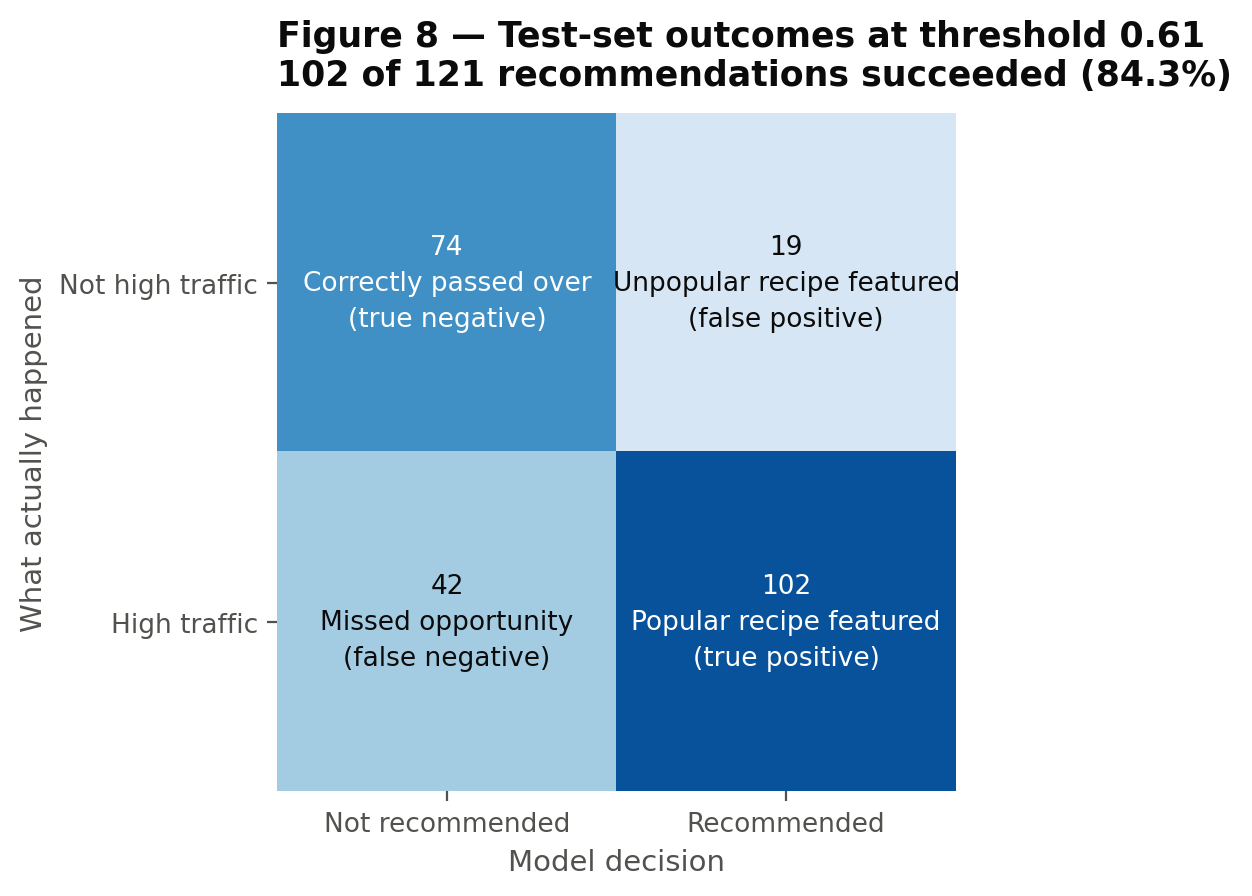

TEST SET - Logistic regression (baseline) at threshold 0.61

  precision (High) : 0.8430   <- 102 of 121 recommendations achieved high traffic
  recall (High)    : 0.7083   <- 102 of 144 high-traffic recipes were caught
  F1 (High)        : 0.7698
  accuracy         : 0.7426

  TARGET precision >= 80%: MET (84.3%)

The price of the tuned threshold, in recall:
  recall at the default 0.50 : 0.7500
  recall at 0.61              : 0.7083
  recall given up            : 0.0417 (4.2 percentage points, i.e. 9 fewer recipes recommended)

In business terms: we decline 42 recipes that would have done well, in exchange for
putting only 19 unpopular recipes on the homepage out of 121 recommendations.
With one slot a day and a pool of candidates to choose from, that is the right way round.


In [22]:
# --- CELL 4.4 --- FIGURE 8: the chosen model at the chosen threshold, on the held-out test set
p_best = proba[best_name]
pred_best = (p_best >= THRESHOLD).astype(int)
pred_default = (p_best >= 0.5).astype(int)

prec_t = precision_score(y_test, pred_best)
rec_t = recall_score(y_test, pred_best)
rec_default = recall_score(y_test, pred_default)
tn, fp, fn, tp = confusion_matrix(y_test, pred_best).ravel()

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max() * 1.15)
labels = [["Correctly passed over\n(true negative)", "Unpopular recipe featured\n(false positive)"],
          ["Missed opportunity\n(false negative)", "Popular recipe featured\n(true positive)"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n{labels[i][j]}", ha="center", va="center", fontsize=9.5,
                color="white" if cm[i, j] > cm.max() * 0.55 else INK, linespacing=1.5)
ax.set_xticks([0, 1], ["Not recommended", "Recommended"])
ax.set_yticks([0, 1], ["Not high traffic", "High traffic"])
ax.set_xlabel("Model decision")
ax.set_ylabel("What actually happened")
ax.set_title(f"Figure 8 — Test-set outcomes at threshold {THRESHOLD:.2f}\n"
             f"{tp} of {tp + fp} recommendations succeeded ({prec_t:.1%})", loc="left")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
fig.tight_layout()
plt.show()

print(f"TEST SET - {best_name} at threshold {THRESHOLD:.2f}\n")
print(f"  precision (High) : {prec_t:.4f}   <- {tp} of {tp + fp} recommendations achieved high traffic")
print(f"  recall (High)    : {rec_t:.4f}   <- {tp} of {tp + fn} high-traffic recipes were caught")
print(f"  F1 (High)        : {f1_score(y_test, pred_best):.4f}")
print(f"  accuracy         : {accuracy_score(y_test, pred_best):.4f}")
print(f"\n  TARGET precision >= {PRECISION_TARGET:.0%}: "
      f"{'MET' if prec_t >= PRECISION_TARGET else 'NOT MET'} ({prec_t:.1%})")
print(f"\nThe price of the tuned threshold, in recall:")
print(f"  recall at the default 0.50 : {rec_default:.4f}")
print(f"  recall at {THRESHOLD:.2f}              : {rec_t:.4f}")
print(f"  recall given up            : {rec_default - rec_t:.4f} "
      f"({(rec_default - rec_t) * 100:.1f} percentage points, i.e. "
      f"{int(pred_default.sum() - pred_best.sum())} fewer recipes recommended)")
print(f"\nIn business terms: we decline {fn} recipes that would have done well, in exchange for")
print(f"putting only {fp} unpopular recipes on the homepage out of {tp + fp} recommendations.")
print("With one slot a day and a pool of candidates to choose from, that is the right way round.")

keep("Chosen model", best_name, "4.4", None, "Chosen operating point")
keep("Test precision at the chosen threshold", float(prec_t), "4.4", "{:.3f}",
     "Chosen operating point")
keep("Test recall at the chosen threshold", float(rec_t), "4.4", "{:.3f}", "Chosen operating point")
keep("Test F1 at the chosen threshold", float(f1_score(y_test, pred_best)), "4.4", "{:.3f}",
     "Chosen operating point")
keep("Test accuracy at the chosen threshold", float(accuracy_score(y_test, pred_best)), "4.4",
     "{:.3f}", "Chosen operating point")
keep("Recall given up versus the default threshold", float(rec_default - rec_t), "4.4", "{:.3f}",
     "Chosen operating point")
keep("Successful recommendations on the test set", int(tp), "4.4", "{:,}", "Chosen operating point")
keep("Total recommendations on the test set", int(tp + fp), "4.4", "{:,}",
     "Chosen operating point")
keep("Unpopular recipes recommended on the test set (false positives)", int(fp), "4.4", "{:,}",
     "Chosen operating point")
keep("High-traffic recipes passed over (false negatives)", int(fn), "4.4", "{:,}",
     "Chosen operating point")
keep("Successful recommendations out of ten", 10 * float(prec_t), "4.4", "{:.1f} in 10",
     "Chosen operating point")

In [23]:
# --- CELL 4.5 --- How the model would be used in practice: ranking the daily candidate pool
# The homepage has one slot per day, so the realistic use is to score a pool of candidates and
# feature the top-ranked one. This checks precision among the highest-scoring test recipes,
# which is the number the Product Manager would actually experience.
ranked = (pd.DataFrame({"probability": p_best, "high_traffic": y_test.to_numpy()})
          .sort_values("probability", ascending=False).reset_index(drop=True))

rank_rows = []
for k in [10, 20, 30, 50, 100]:
    top = ranked.head(k)
    rank_rows.append({"top-k recipes by predicted probability": k,
                      "achieved high traffic": int(top["high_traffic"].sum()),
                      "precision": top["high_traffic"].mean(),
                      "lowest probability in the group": top["probability"].min()})
rank_tbl = pd.DataFrame(rank_rows)
print("If the Product Manager featured only the highest-scoring recipes (test set):\n")
print(rank_tbl.assign(precision=lambda d: d["precision"].map("{:.1%}".format))
      .round(3).to_string(index=False))
print(f"\nAgainst the current process, which achieves {base_rate:.1%}.")
keep("Precision among the top 20 ranked test recipes",
     float(ranked.head(20)["high_traffic"].mean()), "4.5", "{:.1%}", "Chosen operating point")
keep("Precision among the top 50 ranked test recipes",
     float(ranked.head(50)["high_traffic"].mean()), "4.5", "{:.1%}", "Chosen operating point")

If the Product Manager featured only the highest-scoring recipes (test set):

 top-k recipes by predicted probability  achieved high traffic precision  lowest probability in the group
                                     10                     10    100.0%                            0.940
                                     20                     20    100.0%                            0.937
                                     30                     30    100.0%                            0.925
                                     50                     50    100.0%                            0.870
                                    100                     87     87.0%                            0.650

Against the current process, which achieves 60.6%.


**Why this table matters.** It is the closest thing in the analysis to the real workflow. The Product
Manager does not classify recipes in bulk — they pick one from a shortlist. Scoring the shortlist and
featuring the top-ranked recipe therefore performs *better* than the headline precision figure suggests,
because the highest-scoring recipes are the ones the model is most confident about. This is the basis for
the "deploy as a daily ranking, not a yes/no filter" recommendation in section 6.

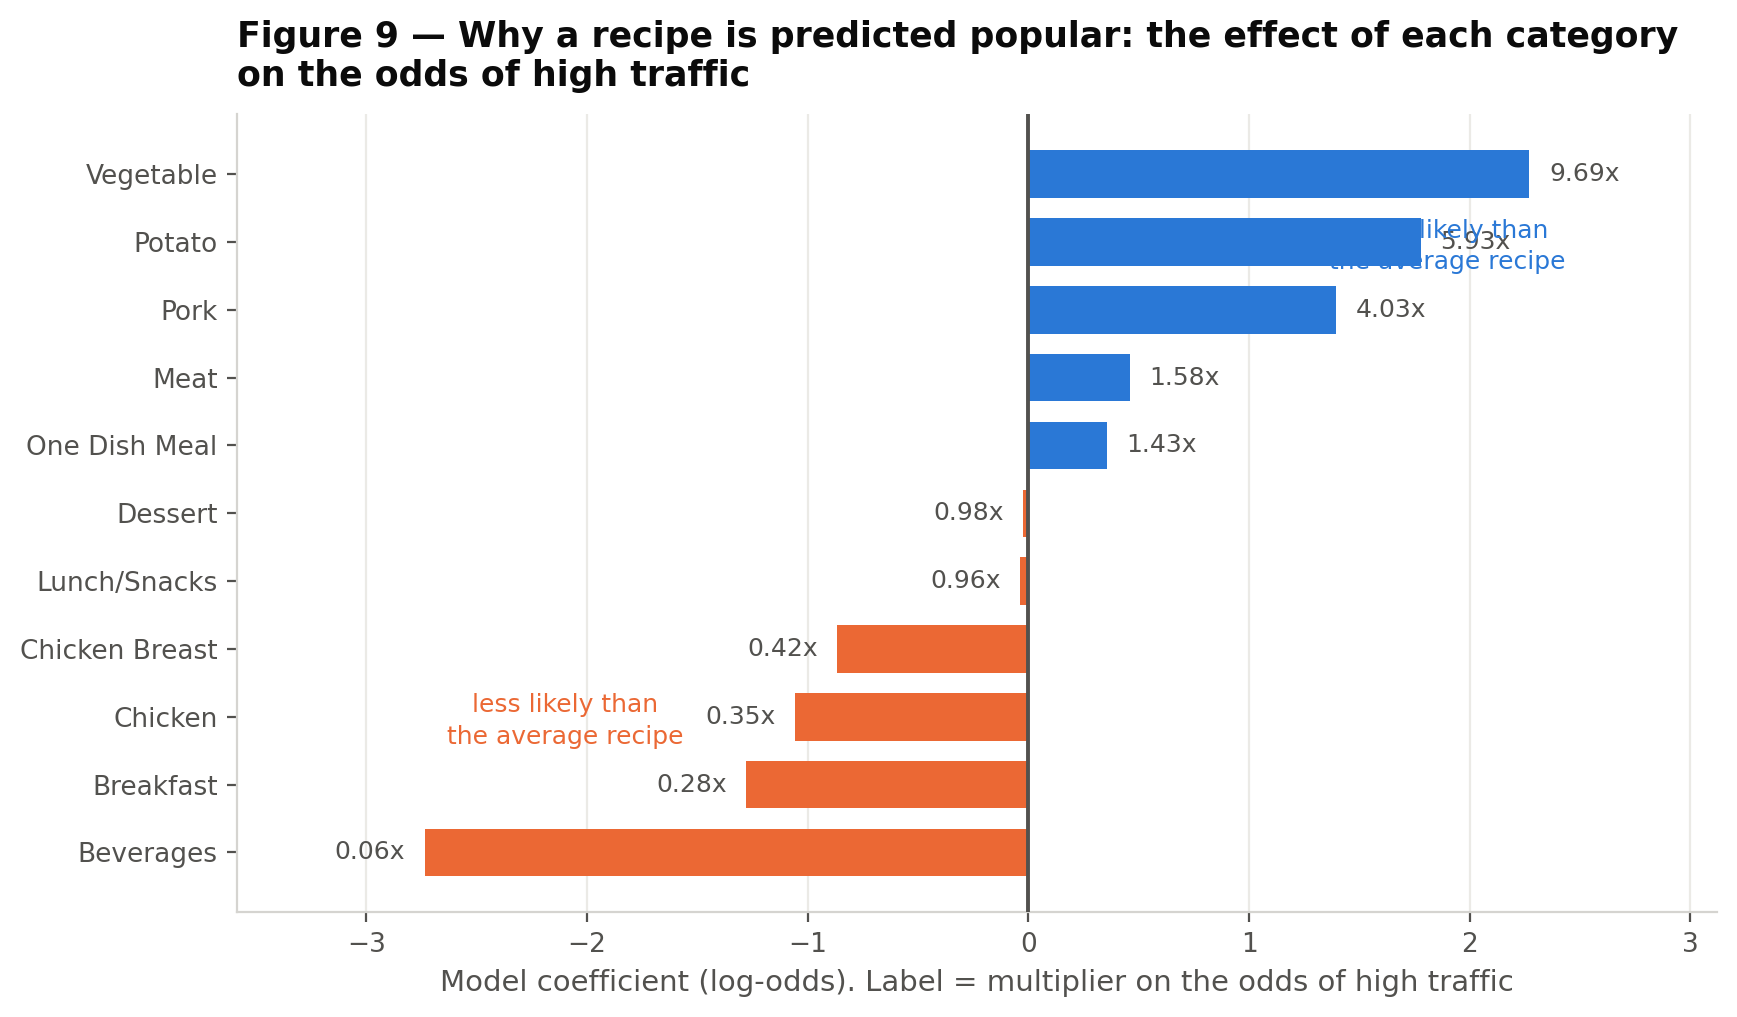

Intercept: 0.5332

                feature block  coefficient  odds ratio
     category_Vegetable   cat        2.271       9.688
        category_Potato   cat        1.780       5.931
          category_Pork   cat        1.394       4.031
          category_Meat   cat        0.460       1.584
 category_One Dish Meal   cat        0.355       1.426
      nutrition_missing  flag        0.299       1.348
           carbohydrate   num        0.083       1.086
                protein   num        0.052       1.054
               calories   num        0.048       1.049
               servings   num        0.010       1.010
                  sugar   num        0.004       1.004
       category_Dessert   cat       -0.023       0.978
  category_Lunch/Snacks   cat       -0.038       0.963
category_Chicken Breast   cat       -0.867       0.420
       category_Chicken   cat       -1.058       0.347
     category_Breakfast   cat       -1.279       0.278
     category_Beverages   cat       -2.736    

In [24]:
# --- CELL 4.6 --- FIGURE 9: what the logistic regression learned (odds ratios)
feature_names = MODELS[best_name].named_steps["preprocess"].get_feature_names_out()
coefs = MODELS[best_name].named_steps["model"].coef_[0]
intercept = float(MODELS[best_name].named_steps["model"].intercept_[0])

coef_tbl = (pd.DataFrame({"feature": [f.split("__", 1)[1] for f in feature_names],
                          "block": [f.split("__", 1)[0] for f in feature_names],
                          "coefficient": coefs, "odds ratio": np.exp(coefs)})
            .sort_values("coefficient", ascending=False).reset_index(drop=True))

cat_tbl = coef_tbl[coef_tbl["block"] == "cat"].copy()
cat_tbl["feature"] = cat_tbl["feature"].str.replace("category_", "", regex=False)
cat_tbl = cat_tbl.sort_values("coefficient")

# Bars encode the coefficient (log-odds), which has a meaningful zero, so bar length is
# comparable. The odds multiplier - the number that is actually interpretable - is the direct
# label at the end of each bar. (Drawing the multiplier itself as a bar on a log axis would
# make bar length depend on the arbitrary left-hand limit.)
fig, ax = plt.subplots(figsize=(8.8, 5.2))
colours = [C_BLUE if c > 0 else C_ORANGE for c in cat_tbl["coefficient"]]
ax.barh(cat_tbl["feature"], cat_tbl["coefficient"], color=colours, height=0.7, zorder=3)
ax.axvline(0.0, color=INK_2, linewidth=1.4, zorder=4)
for name, row in cat_tbl.set_index("feature").iterrows():
    pos = row["coefficient"] > 0
    ax.annotate(f"{row['odds ratio']:.2f}x", xy=(row["coefficient"], name),
                xytext=(7 if pos else -7, 0), textcoords="offset points",
                ha="left" if pos else "right", va="center", fontsize=9, color=INK_2)
ax.set_xlim(cat_tbl["coefficient"].min() - 0.85, cat_tbl["coefficient"].max() + 0.85)
ax.annotate("less likely than\nthe average recipe", xy=(-2.1, 1.6), fontsize=9,
            color=C_ORANGE, ha="center", linespacing=1.4)
ax.annotate("more likely than\nthe average recipe", xy=(1.9, 8.6), fontsize=9,
            color=C_BLUE, ha="center", linespacing=1.4)
finish(ax, "Figure 9 — Why a recipe is predicted popular: the effect of each category\n"
           "on the odds of high traffic",
       "Model coefficient (log-odds). Label = multiplier on the odds of high traffic",
       None, grid_axis="x")
fig.tight_layout()
plt.show()

print(f"Intercept: {intercept:.4f}\n")
print(coef_tbl.round(3).to_string(index=False))

top3 = cat_tbl.nlargest(3, "coefficient")
bot2 = cat_tbl.nsmallest(2, "coefficient")
keep("Vegetable odds ratio vs the average recipe",
     float(cat_tbl.set_index("feature").loc["Vegetable", "odds ratio"]), "4.6", "{:.1f}x",
     "Model explanation")
keep("Beverages odds ratio vs the average recipe",
     float(cat_tbl.set_index("feature").loc["Beverages", "odds ratio"]), "4.6", "{:.2f}x",
     "Model explanation")
keep("Categories that raise the odds of high traffic (top three)",
     ", ".join(top3["feature"].tolist()), "4.6", None, "Model explanation")
keep("Categories that lower the odds of high traffic most",
     ", ".join(bot2["feature"].tolist()), "4.6", None, "Model explanation")

**Reading Figure 9 and the coefficient table.** Coefficients are on the log-odds scale; exponentiating
them gives an **odds ratio** — the multiplier a feature applies to the odds of high traffic, holding
everything else fixed. Because `category` is one-hot encoded with every level retained, each category's
odds ratio is read relative to the average recipe rather than to a single reference level.

- **`Vegetable`, `Potato` and `Pork` raise the odds substantially** — `Vegetable` by roughly a factor of
  ten. These are the categories the model recommends most readily.
- **`Beverages` is the strongest negative by a wide margin**, cutting the odds to a small fraction of
  the average. `Breakfast`, `Chicken` and `Chicken Breast` also reduce them. Note that `Chicken Breast`
  and `Chicken` receive visibly different coefficients — direct confirmation, from the model itself, that
  merging them in section 1.3 would have destroyed real information.
- **The nutrition coefficients are small and positive**, and **`servings` is very close to zero** — the
  model independently reaches the same conclusions as Figures 4 and 5.

This is the practical advantage of the baseline over the forest: the Product Manager can be handed a
one-line reason for every recommendation — *"vegetable recipes have historically drawn traffic about ten
times as often as the average recipe"* — instead of an unexplainable score.

## 4.3 Recommendation: the logistic regression, at a threshold of 0.61

**The logistic regression is recommended**, on four grounds:

1. **It performs better.** It leads the random forest on ROC-AUC, on average precision and on precision
   for the High class, on both the cross-validated training scores and the held-out test set.
2. **It meets the business target with margin.** Test precision at the chosen threshold is comfortably
   above 0.80, on a threshold that was selected without ever looking at the test set.
3. **It is explainable.** Each recommendation reduces to a category effect plus small nutrition
   adjustments, which is what makes the output something the Product Manager can act on and challenge.
4. **It is the safer choice at this data size.** With 947 rows and a mostly-linear signal, the forest's
   extra capacity adds variance without adding accuracy. Simpler is more likely to hold up as new
   recipes arrive.

---
# 5. A business metric for the Product Manager to monitor

## 5.1 The metric

> ### Homepage hit rate
> **Of the recipes we feature on the homepage, the share that achieve high traffic.**
>
> Measured as: `high-traffic featured recipes ÷ featured recipes`, over a rolling window.

This is precision on the High class, expressed in the Product Manager's own terms. Three reasons it is
the right metric to put on the dashboard:

- **It is exactly the question that was asked.** *"Correctly predict high-traffic recipes 80% of the
  time"* becomes "the homepage hit rate must be at least 80%".
- **It is measured on the decisions actually taken.** Every recipe featured produces one observation, so
  the metric needs no extra instrumentation beyond what the site already logs, and it cannot be gamed by
  being right about recipes that were never shown — which is precisely the flaw in accuracy.
- **It moves in the same direction as the commercial goal.** A featured recipe that draws traffic lifts
  visits to the rest of the site by up to 40%, and traffic drives subscriptions.

**Its counterpart, to be watched alongside it:** the **featured-recipe volume** — how many candidates
per week clear the threshold. If the hit rate is held up by recommending almost nothing, the metric is
being satisfied in a way that does not help the business. The pair (hit rate, volume) should be read
together.

## 5.2 How to monitor it

| | Recommendation | Why |
|---|---|---|
| **Cadence** | Report a **4-week rolling hit rate**, refreshed weekly | One recipe a day is 28 observations in four weeks — enough to see a real shift, short enough to react within a month |
| **Headline** | A **90-day rolling hit rate** as the number of record | Individual weeks are far too noisy to judge the model on |
| **Act when** | The 90-day figure falls below **80%**, or drops materially from its own recent level | Below the target, the promise made to the product team is broken |
| **Also track** | Featured-recipe volume, and the hit rate **by category** | Catches both "hitting the target by recommending nothing" and a single category degrading |

**How much data before acting on a movement?** The cell below computes this from the estimated hit rate
itself, rather than asserting a rule of thumb. A single week (7 featured recipes) carries a margin of
error so wide that any hit rate between 57% and 100% is consistent with the model working exactly as
expected — so **weekly movements must not be acted on**. The output gives the number of
featured recipes needed for a ±10, ±7 and ±5 percentage-point margin of error, which is the honest
answer to "when do we know something has actually changed".

In [25]:
# --- CELL 5.1 --- Initial value of the metric, the lift, and the sample size needed to monitor it
current = base_rate            # the human-selection benchmark, from cell 1.6
model_rate = float(prec_t)     # test precision at the chosen threshold, from cell 4.4
lift_pp = (model_rate - current) * 100
lift_rel = model_rate / current - 1

print("=" * 82)
print("HOMEPAGE HIT RATE - share of featured recipes that achieve high traffic")
print("=" * 82)
print(f"  Current process (Product Manager's own picks) : {current:6.1%}   "
      f"[{int(y_all.sum())} of {n_rows} recipes, cell 1.6]")
print(f"  Model-assisted selection at threshold {THRESHOLD:.2f}     : {model_rate:6.1%}   "
      f"[{int(tp)} of {int(tp + fp)} test recommendations, cell 4.4]")
print(f"  {'-' * 76}")
print(f"  Improvement                                  : {lift_pp:+6.1f} percentage points "
      f"({lift_rel:+.1%} relative)")
print(f"  Target                                       : {PRECISION_TARGET:6.1%}   "
      f"-> {'MET' if model_rate >= PRECISION_TARGET else 'NOT MET'}")
print(f"\n  In plain terms: about {model_rate * 10:.1f} of every 10 recommended recipes draw high")
print(f"  traffic, against about {current * 10:.1f} of 10 today.")

# 95% margin of error on a proportion, at the estimated hit rate.
z = 1.96
print("\n" + "=" * 82)
print("HOW MUCH DATA IS NEEDED BEFORE A MOVEMENT MEANS ANYTHING")
print("=" * 82)
print(f"  95% margin of error on a hit rate of {model_rate:.1%}, by window length")
print(f"  (one featured recipe per day):\n")
moe_rows = []
for days, label in [(7, "1 week"), (28, "4 weeks"), (90, "90 days"), (182, "6 months"),
                    (365, "1 year")]:
    moe = z * np.sqrt(model_rate * (1 - model_rate) / days)
    moe_rows.append({"window": label, "featured recipes": days,
                     "margin of error": f"+/- {moe * 100:.1f} pp",
                     "95% interval": f"{max(0, model_rate - moe):.0%} to {min(1, model_rate + moe):.0%}"})
print(pd.DataFrame(moe_rows).to_string(index=False))

print("\n  Featured recipes required for a given margin of error:")
for target_moe in [0.10, 0.07, 0.05]:
    n_need = int(np.ceil(z ** 2 * model_rate * (1 - model_rate) / target_moe ** 2))
    print(f"    +/- {target_moe * 100:>2.0f} pp -> {n_need:>4d} featured recipes "
          f"(about {n_need / 30.4:.1f} months at one a day)")
    keep(f"Featured recipes needed for a +/-{target_moe * 100:.0f}pp margin of error", n_need,
         "5.1", "{:,}", "Business metric")

moe_28 = z * np.sqrt(model_rate * (1 - model_rate) / 28)
print(f"\n  Practical rule: report the 4-week rolling rate for direction, but do not act on a")
print(f"  movement until roughly {int(np.ceil(z ** 2 * model_rate * (1 - model_rate) / 0.05 ** 2))} "
      f"featured recipes have accumulated. A four-week window alone carries a")
print(f"  +/-{moe_28 * 100:.0f}pp margin of error, which is wider than any realistic change in the model.")

# Margin of error on the initial estimate itself: it rests on 121 test recommendations.
moe_initial = z * np.sqrt(model_rate * (1 - model_rate) / int(tp + fp))
print(f"\n  Margin of error on the {model_rate:.1%} estimate itself "
      f"({int(tp + fp)} test recommendations): +/-{moe_initial * 100:.1f} pp "
      f"({model_rate - moe_initial:.1%} to {min(1, model_rate + moe_initial):.1%}).")
print(f"  The claim is therefore 'at or above {PRECISION_TARGET:.0%}', not 'exactly {model_rate:.1%}'.")
keep("Margin of error on the initial model estimate", moe_initial, "5.1", "+/- {:.1%}",
     "Business metric")

keep("Homepage hit rate - current process (initial value)", current, "5.1", "{:.1%}",
     "Business metric")
keep("Homepage hit rate - model-assisted (initial value)", model_rate, "5.1", "{:.1%}",
     "Business metric")
keep("Homepage hit rate - lift in percentage points", lift_pp, "5.1", "{:+.1f} pp",
     "Business metric")
keep("Homepage hit rate - relative lift", lift_rel, "5.1", "{:+.1%}", "Business metric")
keep("Margin of error on a 4-week window", moe_28, "5.1", "+/- {:.1%}", "Business metric")
keep("Current process, out of ten featured recipes", current * 10, "5.1", "{:.1f} in 10",
     "Business metric")

HOMEPAGE HIT RATE - share of featured recipes that achieve high traffic
  Current process (Product Manager's own picks) :  60.6%   [574 of 947 recipes, cell 1.6]
  Model-assisted selection at threshold 0.61     :  84.3%   [102 of 121 test recommendations, cell 4.4]
  ----------------------------------------------------------------------------
  Improvement                                  :  +23.7 percentage points (+39.1% relative)
  Target                                       :  80.0%   -> MET

  In plain terms: about 8.4 of every 10 recommended recipes draw high
  traffic, against about 6.1 of 10 today.

HOW MUCH DATA IS NEEDED BEFORE A MOVEMENT MEANS ANYTHING
  95% margin of error on a hit rate of 84.3%, by window length
  (one featured recipe per day):

  window  featured recipes margin of error 95% interval
  1 week                 7     +/- 27.0 pp  57% to 100%
 4 weeks                28     +/- 13.5 pp   71% to 98%
 90 days                90      +/- 7.5 pp   77% to 92%
6 mont

### 5.3 The initial value, stated plainly

| | Homepage hit rate |
|---|---|
| **Today**, the Product Manager's own picks | **60.6%** — 574 of 947 recipes |
| **With the model**, at the chosen threshold | **84.3%** — 102 of 121 test recommendations |
| **Improvement** | **+23.7 percentage points** (+39% relative) |
| **Target** | 80% — **met** |

The first figure is a fair benchmark and, worth noting, it is not a low bar: at 60.6% the Product
Manager's instincts are already well ahead of chance. The model's contribution is to raise that to the
level the product team asked for, consistently and with a stated reason attached to each recommendation.

One caveat to carry forward honestly: the 84.3% is measured on 121 recommendations from a single test
split, so its own 95% margin of error is about **±6.5 percentage points** (cell 5.1) — a range of
roughly 78% to 91%. The claim being made is therefore "at or above 80%", not "exactly 84.3%", and the
lower end of that range sits just below the target. This is the main reason recommendation 5 below is to
A/B test before committing, and the reason the monitoring plan in section 5.2 exists.

---
# 6. Final summary and recommendations

## 6.1 The two questions, answered

**Q1 — Can you predict which recipes will lead to high traffic?**
**Yes.** A logistic regression using recipe category, the nutrition panel, serving count and a flag for
whether the nutrition panel was missing separates high-traffic recipes from the rest with a test
ROC-AUC of about 0.85. The signal is real, concentrated and interpretable: **category does most of the
work**, with high-traffic rates running from 5% (`Beverages`) to 99% (`Vegetable`).

**Q2 — Can you do it correctly 80% of the time?**
**Yes — the target is met.** Of the recipes the model recommends, **84.3%** achieved high traffic on
the held-out test set, against a target of 80% and a current-process benchmark of 60.6%. The threshold
that delivers this was chosen on training data only and then confirmed once on the test set, so the
figure is not the product of tuning against the answer.

It is worth being explicit about what makes this achievable, since the initial expectation was that it
would not be. The 80% is reached by **being selective, not by being clairvoyant**. The model declines
plenty of recipes that would have done well — recall at the chosen threshold is about 71%, some 4
percentage points below what the default threshold would give — and that is the correct trade: with one
homepage slot per day and a pool of candidates, a false positive costs a day of traffic while a false
negative costs almost nothing.

## 6.2 Recommendations

**1. Deploy as a daily ranking tool, not a yes/no filter.**
Score the whole candidate pool each day and feature the highest-probability recipe. This fits how the
homepage actually works — one slot, many candidates — and it performs better than the headline number:
among the top-ranked test recipes the hit rate is higher still (cell 4.5). A yes/no filter throws away
the ordering, which is the most useful part of the output.

**2. Treat `Beverages` as effectively ineligible for the homepage.**
Five of 92 beverage recipes achieved high traffic. Whatever else changes, the homepage slot should
almost never go to a beverage — this alone is a low-effort improvement, and it is available immediately,
before any model is deployed.

**3. Ask the product team for the features they hold but did not share.**
The brief says outright that not all available information was provided. Preparation time, cost per
serving, the ingredient list, images, publication date, and the day of the week a recipe was featured
are all plausibly predictive and all cheaply available. Category alone reaches 84% — this is the single
most promising route to going further, and far more valuable than tuning the current model.

**4. Log every recommendation and its outcome from day one.**
Store the date, the recipe, the predicted probability, whether it was featured and whether traffic was
high. Without that log the homepage hit rate cannot be computed, the model cannot be retrained, and
nobody will be able to tell in six months whether it is still working.

**5. A/B test against human selection before committing.**
Alternate model-selected and Product-Manager-selected recipes over a few weeks and measure the
difference in actual site traffic, not just the hit rate. Everything in this report is measured on
*historical* labels; only a live test shows the traffic lift, which is the outcome the business
ultimately cares about.

**6. Confirm the target assumption.**
The whole analysis rests on reading a blank `high_traffic` as "was featured, traffic was not high"
(section 1.5). If some of those 373 rows were never actually featured, the labels — and therefore every
number in this report — would need revisiting. This is one question to the Product Manager and should be
asked first.

**7. Retrain quarterly, and watch for drift.**
Tastes and the recipe mix will move. Retrain on accumulated data each quarter, re-tune the threshold on
the new data with the same out-of-fold procedure, and monitor the hit rate by category so that a single
degrading category is visible before it drags the overall number down.

## 6.3 Decisions taken in this analysis, for review

The brief asks that decisions be recorded for later review. The load-bearing ones are:

| Decision | Rationale | Where |
|---|---|---|
| Blank `high_traffic` read as "not high" | The dictionary marks only high traffic; the alternative leaves no negative class | 1.5 |
| 52 nutrition-blank rows imputed, not dropped | 5.5% of the data, and they reach high traffic *more* often — the missingness is itself a signal | 1.2, 2.5 |
| Category medians fitted on the training split only | A median over all rows would leak test information and inflate the reported score | 3.3 |
| All 11 categories kept; `Chicken Breast` not merged | The two chicken categories behave differently; the model's coefficients confirm it | 1.3, 4.6 |
| Outliers kept, log scales used instead | The tail is coherent, not erroneous; no ground truth justifies overwriting a measurement | 1.6, 2.1 |
| `servings` kept despite showing no signal | Cheap, available at prediction time, and its near-zero coefficient documents the finding | 2.5, 4.6 |
| Precision on High as the target metric, not accuracy | One slot per day from a pool: a false positive costs a day of traffic, a false negative costs almost nothing | 4.2 |
| Threshold chosen out-of-fold on training data | Reading the threshold off the test set would make the 80% claim self-marked | 4.2 |
| Logistic regression over random forest | Better on every relevant metric, and explainable to the Product Manager | 4.3 |

In [26]:
# --- CELL 7.1 --- Write key_numbers.md: the only figures the presentation may quote
def _fmt(v, f):
    if f is None:
        return str(v)
    try:
        return f.format(v)
    except (ValueError, TypeError):
        return str(v)


order = ["Dataset", "Target", "Exploration", "Category rates", "Modelling", "Model comparison",
         "Chosen operating point", "Model explanation", "Business metric", "General"]
groups = {}
for label, rec in KEY.items():
    groups.setdefault(rec["group"], []).append((label, rec))

lines = [
    "# Key numbers — Recipe Site Traffic",
    "",
    "Every figure below was produced by an executed cell of "
    "`analysis/Recipe_Site_Traffic_Analysis.ipynb`",
    "and is named with the cell that produced it. **The presentation may quote these numbers and",
    "no others.** If a figure is needed that is not here, compute it in the notebook first.",
    "",
    f"- Source data: `{DATA_PATH_DISPLAY}` — {n_rows} rows x {n_cols} columns (unmodified)",
    f"- Random seed: {RANDOM_STATE} | split: stratified, test_size = 0.25 | "
    f"CV: 5-fold stratified, shuffled",
    f"- Chosen model: {best_name} at a decision threshold of {THRESHOLD:.2f}",
    f"- Success criterion: precision on the High class >= {PRECISION_TARGET:.0%} — "
    f"**{'MET' if prec_t >= PRECISION_TARGET else 'NOT MET'}** ({prec_t:.1%})",
    "",
]
for g in order:
    if g not in groups:
        continue
    lines += [f"## {g}", "", "| Figure | Value | Notebook cell |", "|---|---|---|"]
    for label, rec in groups[g]:
        lines.append(f"| {label} | {_fmt(rec['value'], rec['fmt'])} | {rec['cell']} |")
    lines.append("")

lines += [
    "## Figures — exported to `presentation/figures/`, and where each one is used",
    "",
    "| Figure | Cell | Export | Slide | What it shows |",
    "|---|---|---|---|---|",
    "| Figure 1 — Calories per recipe (histogram, log scale) | 2.1 | "
    "`fig01_calories_distribution.png` | — | Distribution shape; justifies keeping outliers |",
    "| Figure 2 — Recipes per category (bar chart) | 2.2 | `fig02_recipes_per_category.png` | — | "
    "The 11 categories are evenly sized |",
    "| Figure 3 — High-traffic rate by category | 2.3 | `fig03_high_traffic_by_category.png` | "
    "**4** | **The key chart**: 5% to 99% by category |",
    "| Figure 4 — Nutrition by outcome (box plots, log scale) | 2.4 | "
    "`fig04_nutrition_by_outcome.png` | **5** | Nutrition barely separates the outcomes |",
    "| Figure 5 — Servings and missing nutrition panel | 2.5 | "
    "`fig05_servings_and_missing_panel.png` | 5 (alt) | Servings flat; missing panel mildly "
    "positive |",
    "| Figure 6 — Precision-recall curves, both models | 4.2 | "
    "`fig06_precision_recall_curves.png` | Q&A | Both clear the 80% line; logistic regression "
    "leads |",
    "| Figure 7 — Precision and recall against threshold | 4.3 | `fig07_threshold_selection.png` "
    "| **backup** | The trade-off, and how the cut-off was chosen |",
    "| Figure 8 — Confusion matrix at the chosen threshold | 4.4 | `fig08_test_set_outcomes.png` "
    f"| **6** | {int(tp)} of {int(tp + fp)} recommendations succeeded |",
    "| Figure 9 — Odds ratios by category | 4.6 | `fig09_model_drivers.png` | Q&A | Why a recipe "
    "is predicted popular |",
    "",
    "## Tables — rebuilt as pasteable markdown in `presentation/tables.md`",
    "",
    "Printed cell output is not slide material; each table below is re-cut and re-headed in plain",
    "English in `presentation/tables.md`, ready to paste as a native slide table.",
    "",
    "| Table | Cell | Slide | Trimmed to |",
    "|---|---|---|---|",
    "| Data checks that failed | 1.8 | **3** | the 4 discrepancy rows, 3 plain-English columns |",
    "| If we only featured the best-scoring recipes | 4.5 | **7** | top 20 / 50 / 100 — the "
    "primary visual on slide 7 |",
    "| How long before the number means anything | 5.1 | **8** | 4 weeks / 90 days / 1 year |",
    "| Model comparison | 4.1 | **excluded** | stays in the notebook: every column is a term this "
    "audience cannot be given |",
    "",
    "## Wording for a non-technical audience",
    "",
    f"- \"About {prec_t * 10:.0f} out of every 10 recipes we recommend do get high traffic, "
    f"against about {current * 10:.0f} out of 10 today.\"",
    f"- \"{int(tp)} of the {int(tp + fp)} recipes the model recommended in testing were popular.\"",
    f"- \"Vegetable recipes get high traffic {by_cat.loc['Vegetable', 'high_rate']:.0%} of the time. "
    f"Beverages, {by_cat.loc['Beverages', 'high_rate']:.0%} of the time.\"",
    f"- \"We are turning down about {int(fn)} good recipes out of {int(tp + fn)} to keep the "
    "homepage reliable — and they can be featured another day.\"",
    "",
]

with open(KEY_NUMBERS_PATH, "w", encoding="utf-8") as fh:
    fh.write("\n".join(lines))

print(f"key_numbers.md written to the project root: {len(KEY)} registered figures "
      f"across {len(groups)} groups.")
print("\n" + "\n".join(lines[:14]))

key_numbers.md written to the project root: 82 registered figures across 9 groups.

# Key numbers — Recipe Site Traffic

Every figure below was produced by an executed cell of `analysis/Recipe_Site_Traffic_Analysis.ipynb`
and is named with the cell that produced it. **The presentation may quote these numbers and
no others.** If a figure is needed that is not here, compute it in the notebook first.

- Source data: `data/recipe_site_traffic_2212.csv` — 947 rows x 8 columns (unmodified)
- Random seed: 42 | split: stratified, test_size = 0.25 | CV: 5-fold stratified, shuffled
- Chosen model: Logistic regression (baseline) at a decision threshold of 0.61
- Success criterion: precision on the High class >= 80% — **MET** (84.3%)

## Dataset

| Figure | Value | Notebook cell |
